<table align="center">
  <td align="center"><a target="_blank" href="https://colab.research.google.com/github/sherifmost/DeepLearning/blob/master/Labs/lab2/lab2.ipynb">
        <img src="http://introtodeeplearning.com/images/colab/colab.png?v2.0"  style="padding-bottom:5px;" />Run in Google Colab</a></td>
</table>

# Assignment 1: Multinominal Classification

![Multinominal Classification Network](https://github.com/KhaledElTahan/DeepLearning/blob/master/Labs/lab2/multinominal_classification_net.png?raw=1)

## 1.1 Problem Statement

In this assignment we will be addressing the task of multinominal classification of handwritten digits from the famous MNIST dataset.

The MNIST dataset consists of 60,000 training images and 10,000 test images.  Our classes are the digits 0-9.

You are required to build 2 models to solve this problem:
1. A simple model using fully connected layers.
2. A model using Convolutional Neural Network (CNN) before applying the simple model.

You should perform different experiments on the two models, observe the difference in **accuracy** and report them.

At the end you should perform **machine learning interpretability analysis** and report your observations.

## 1.2 Problem Details

### 1.2.1 Dataset Loading

#### Import Needed packages

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import random
from progressbar import progressbar

#### Load Dataset

In [ ]:
mnist = tf.keras.datasets.mnist
(train_images, train_labels), (val_images, val_labels) = mnist.load_data()

train_images = np.expand_dims(train_images, axis=-1) / 255.
train_labels = np.int64(train_labels)

val_images = np.expand_dims(val_images, axis=-1) / 255.
val_labels = np.int64(val_labels)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


#### Plot Dataset Sample

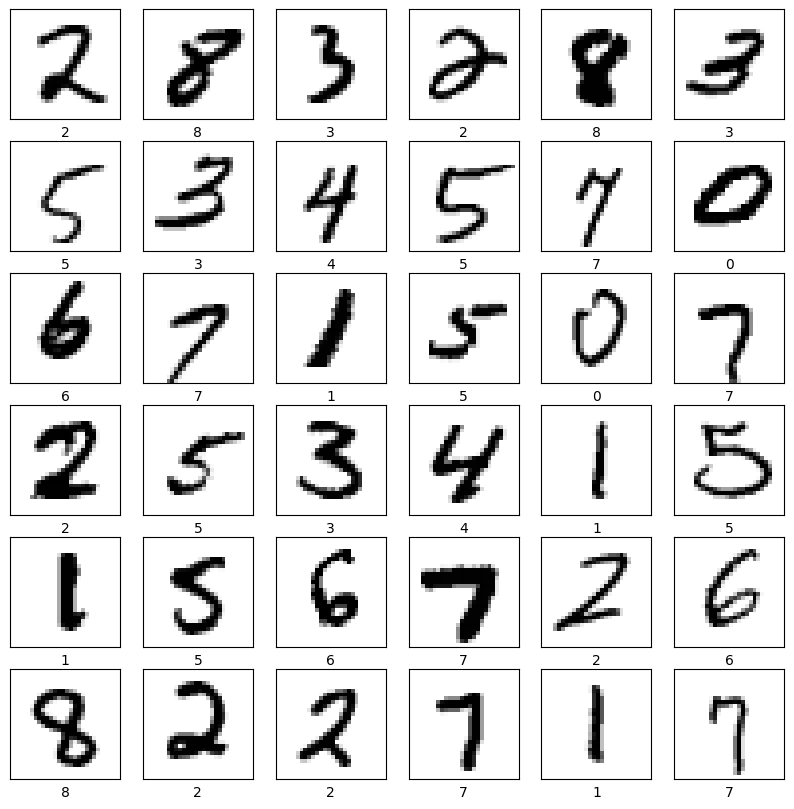

In [ ]:
plt.figure(figsize=(10, 10))
random_inds = np.random.choice(60000, 36)
for i in range(36):
    plt.subplot(6, 6, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    image_ind = random_inds[i]
    plt.imshow(np.squeeze(train_images[image_ind]), cmap=plt.cm.binary)
    plt.xlabel(train_labels[image_ind])

### 1.2.2 Fully Connected Neural Network Solution

Build a neural network, using tf.keras, consisting of 2 fully connected layers and apply this to the digit classification task, Our network will ultimately output a probability distribution over the 10 digit classes (0-9).

![Two Layer Neural Network](https://github.com/KhaledElTahan/DeepLearning/blob/master/Labs/lab2/2layer_nn.png?raw=1)

#### Define the Two-Layer Neural Network

**TODO**

1. Define two layer neural network exactly as in the previous figure by adding two [dense layers](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense).
2. Try different [activation functions](https://keras.io/api/layers/#layer-activations) for both layers (ReLU, Tanh, and other activations for first layer - Softmax, and other activations for output layer), and report the difference in **accuracy** and plots.
3. Try different [regularization kernerls](https://keras.io/api/layers/#layer-weight-regularizers), and [regularization layers](https://keras.io/api/layers/#regularization-layers) (L1, L2, Dropout, and other regularizations), and report the difference in **accuracy** and plots.

**Make sure to add the following to the report:**


*   Include the default case for the activation function of the first layer using ReLU (2.1 in the report)
*   Try out two different activation functions for the first layer and include them (2.2, 2.3 in the report)
*   Include the default case for the activation function of the output layer using Softmax (2.4 in the report)
*   Try out another activation function for the output layer (2.5 in the report)
*   Include the default case where no regularization is added (2.6 in the report)
*   Experiment with two different regularization approaches (2.7 and 2.8 in the report)



In [ ]:
def build_fc_model(activation_first='relu', activation_output='softmax', regularizer=None):
    fc_model = tf.keras.Sequential([
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation=activation_first, kernel_regularizer=regularizer),
        tf.keras.layers.Dense(10, activation=activation_output)
    ])
    return fc_model

#### Compile the Two-Layer Neural Network

**TODO**

1. Try different [optimizers](https://keras.io/api/optimizers/), and report the difference in **accuracy** and plots.
2. **For each optimizer**, try different learning rates and other hyperparameters (If applicable), and report the difference in **accuracy** and plots.
3. Try different [loss functions](https://keras.io/api/losses/), and report the difference in **accuracy** and plots.

**Make sure to add the following to the report:**


*   Include the default case for the optimizer and its hyperparameters using SGD(lr = 0.1) (2.9 in the report)
*   Experiment with other combinations of optimizers and their hyperparameters (2.10, 2.11, 2.12 in the report)
*   Include the default case for the loss using cross entropy (2.13 in the report)
*   Try out two other loss functions (2.14, 2.15 in the report)



In [ ]:
fc_model = build_fc_model()

fc_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#### Print the Two-Layer Neural Network Model Summary

In [ ]:
fc_model.build((None, train_images.shape[1], train_images.shape[2], train_images.shape[3]))
fc_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

#### Train the Two-Layer Neural Network

In [ ]:
BATCH_SIZE = 64
EPOCHS = 10

nn_hist = fc_model.fit(train_images, train_labels, validation_data=(val_images, val_labels), batch_size=BATCH_SIZE, epochs=EPOCHS)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8406 - loss: 0.5808 - val_accuracy: 0.9259 - val_loss: 0.2487
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9403 - loss: 0.2141 - val_accuracy: 0.9511 - val_loss: 0.1656
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9556 - loss: 0.1591 - val_accuracy: 0.9604 - val_loss: 0.1362
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9641 - loss: 0.1283 - val_accuracy: 0.9650 - val_loss: 0.1171
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9711 - loss: 0.1043 - val_accuracy: 0.9688 - val_loss: 0.1044
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9751 - loss: 0.0915 - val_accuracy: 0.9710 - val_loss: 0.0970
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9794 - loss: 0.0759 - val_accuracy: 0.9727 - val_loss: 0.0915
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9793 - loss: 0.0731 - val_accuracy: 0.

#### Plot the Accuracy Curve for the Two-Layer Neural Network

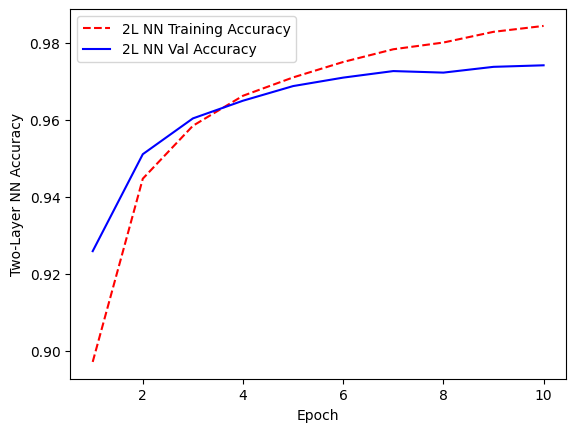

In [ ]:
training_acc = nn_hist.history['accuracy']
val_acc = nn_hist.history['val_accuracy']

epoch_count = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['2L NN Training Accuracy', '2L NN Val Accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Two-Layer NN Accuracy')
plt.show()

#### Evaluate the Two-Layer Neural Network

In [ ]:
val_loss, val_acc = fc_model.evaluate(val_images, val_labels)

print('Validation Accuracy:', val_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9701 - loss: 0.0986
Validation Accuracy: 0.9742000102996826


In [ ]:
# 2.2) Activation Function First Layer - Tanh
fc_model_tanh = build_fc_model(activation_first='tanh')

fc_model_tanh.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fc_model_tanh.build((None, train_images.shape[1], train_images.shape[2], train_images.shape[3]))
fc_model_tanh.summary()

BATCH_SIZE = 64
EPOCHS = 10

nn_hist_tanh = fc_model_tanh.fit(train_images, train_labels, validation_data=(val_images, val_labels), batch_size=BATCH_SIZE, epochs=EPOCHS)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8438 - loss: 0.5610 - val_accuracy: 0.9288 - val_loss: 0.2531
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9301 - loss: 0.2481 - val_accuracy: 0.9444 - val_loss: 0.2007
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9445 - loss: 0.1986 - val_accuracy: 0.9506 - val_loss: 0.1689
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9554 - loss: 0.1577 - val_accuracy: 0.9587 - val_loss: 0.1432
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9633 - loss: 0.1313 - val_accuracy: 0.9627 - val_loss: 0.1278
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9664 - loss: 0.1152 - val_accuracy: 0.9659 - val_loss: 0.1161
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9711 - loss: 0.0992 - val_accuracy: 0.9673 - val_loss: 0.1078
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9746 - loss: 0.0895 - val_accuracy: 0.

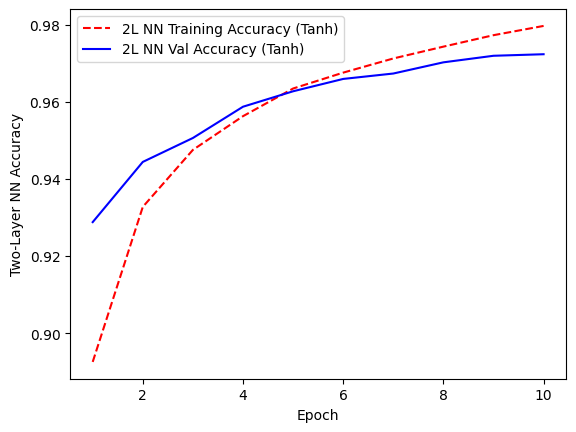

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9672 - loss: 0.1055
Validation Accuracy (Tanh): 0.9722999930381775


In [ ]:
# Plot for 2.2: Tanh
training_acc = nn_hist_tanh.history['accuracy']
val_acc = nn_hist_tanh.history['val_accuracy']

epoch_count = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['2L NN Training Accuracy (Tanh)', '2L NN Val Accuracy (Tanh)'])
plt.xlabel('Epoch')
plt.ylabel('Two-Layer NN Accuracy')
plt.show()

val_loss, val_acc = fc_model_tanh.evaluate(val_images, val_labels)
print('Validation Accuracy (Tanh):', val_acc)

In [ ]:
# 2.3) Activation Function First Layer - Sigmoid
fc_model_sigmoid = build_fc_model(activation_first='sigmoid')

fc_model_sigmoid.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fc_model_sigmoid.build((None, train_images.shape[1], train_images.shape[2], train_images.shape[3]))
fc_model_sigmoid.summary()

BATCH_SIZE = 64
EPOCHS = 10

nn_hist_sigmoid = fc_model_sigmoid.fit(train_images, train_labels, validation_data=(val_images, val_labels), batch_size=BATCH_SIZE, epochs=EPOCHS)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7190 - loss: 1.1286 - val_accuracy: 0.8975 - val_loss: 0.3843
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8947 - loss: 0.3784 - val_accuracy: 0.9121 - val_loss: 0.3120
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9096 - loss: 0.3198 - val_accuracy: 0.9189 - val_loss: 0.2853
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9174 - loss: 0.2873 - val_accuracy: 0.9243 - val_loss: 0.2664
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9245 - loss: 0.2654 - val_accuracy: 0.9288 - val_loss: 0.2506
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9266 - loss: 0.2539 - val_accuracy: 0.9320 - val_loss: 0.2367
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9312 - loss: 0.2392 - val_accuracy: 0.9360 - val_loss: 0.2238
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9365 - loss: 0.2204 - val_accuracy: 0.

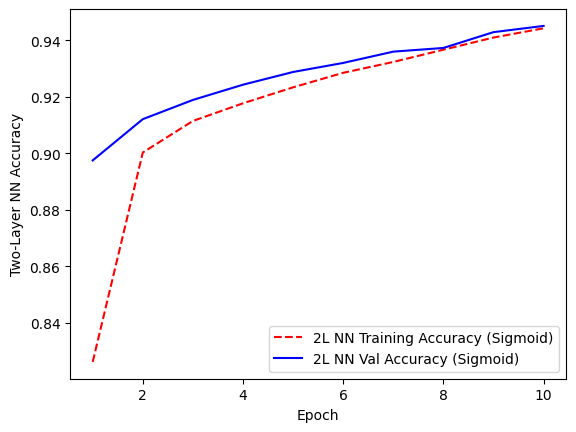

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9340 - loss: 0.2208
Validation Accuracy (Sigmoid): 0.9451000094413757


In [ ]:
# Plot for 2.3: Sigmoid
training_acc = nn_hist_sigmoid.history['accuracy']
val_acc = nn_hist_sigmoid.history['val_accuracy']

epoch_count = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['2L NN Training Accuracy (Sigmoid)', '2L NN Val Accuracy (Sigmoid)'])
plt.xlabel('Epoch')
plt.ylabel('Two-Layer NN Accuracy')
plt.show()

val_loss, val_acc = fc_model_sigmoid.evaluate(val_images, val_labels)
print('Validation Accuracy (Sigmoid):', val_acc)

In [ ]:
# 2.5) Activation Function Output Layer - 2: Linear
fc_model_linear = build_fc_model(activation_first='relu', activation_output='linear')

fc_model_linear.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fc_model_linear.build((None, train_images.shape[1], train_images.shape[2], train_images.shape[3]))
fc_model_linear.summary()

BATCH_SIZE = 64
EPOCHS = 10

nn_hist_linear = fc_model_linear.fit(train_images, train_labels, validation_data=(val_images, val_labels), batch_size=BATCH_SIZE, epochs=EPOCHS)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.1227 - loss: 4.3442 - val_accuracy: 0.0982 - val_loss: 3.7768
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.0966 - loss: 3.7762 - val_accuracy: 0.0982 - val_loss: 3.7768
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.0980 - loss: 3.8263 - val_accuracy: 0.1061 - val_loss: 2.2908
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.1081 - loss: 2.3003 - val_accuracy: 0.1010 - val_loss: 2.3026
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.1017 - loss: 2.3026 - val_accuracy: 0.1010 - val_loss: 2.3026
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1030 - loss: 2.3026 - val_accuracy: 0.1010 - val_loss: 2.3026
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.1018 - loss: 2.3026 - val_accuracy: 0.1010 - val_loss: 2.3026
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.1033 - loss: 2.3026 - val_accuracy: 0.

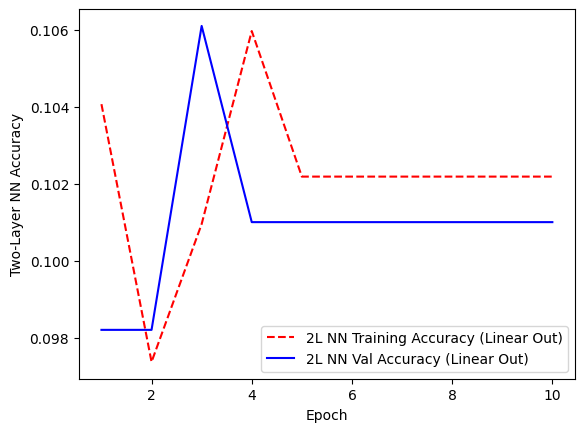

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1009 - loss: 2.3026
Validation Accuracy (Linear Output): 0.10100000351667404


In [ ]:
# Plot for 2.5: Linear Output
training_acc = nn_hist_linear.history['accuracy']
val_acc = nn_hist_linear.history['val_accuracy']

epoch_count = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['2L NN Training Accuracy (Linear Out)', '2L NN Val Accuracy (Linear Out)'])
plt.xlabel('Epoch')
plt.ylabel('Two-Layer NN Accuracy')
plt.show()

val_loss, val_acc = fc_model_linear.evaluate(val_images, val_labels)
print('Validation Accuracy (Linear Output):', val_acc)

In [ ]:
# 2.6) Regularizer (Default: None)
fc_model_noreg = build_fc_model(activation_first='relu', activation_output='softmax', regularizer=None)

fc_model_noreg.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fc_model_noreg.build((None, train_images.shape[1], train_images.shape[2], train_images.shape[3]))
fc_model_noreg.summary()

BATCH_SIZE = 64
EPOCHS = 10

nn_hist_noreg = fc_model_noreg.fit(train_images, train_labels, validation_data=(val_images, val_labels), batch_size=BATCH_SIZE, epochs=EPOCHS)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8373 - loss: 0.5954 - val_accuracy: 0.9279 - val_loss: 0.2557
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9389 - loss: 0.2142 - val_accuracy: 0.9444 - val_loss: 0.1846
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9548 - loss: 0.1564 - val_accuracy: 0.9581 - val_loss: 0.1395
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9647 - loss: 0.1267 - val_accuracy: 0.9674 - val_loss: 0.1163
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9703 - loss: 0.1041 - val_accuracy: 0.9660 - val_loss: 0.1125
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9742 - loss: 0.0914 - val_accuracy: 0.9706 - val_loss: 0.0992
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9775 - loss: 0.0777 - val_accuracy: 0.9729 - val_loss: 0.0898
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9810 - loss: 0.0678 - val_accuracy: 0.

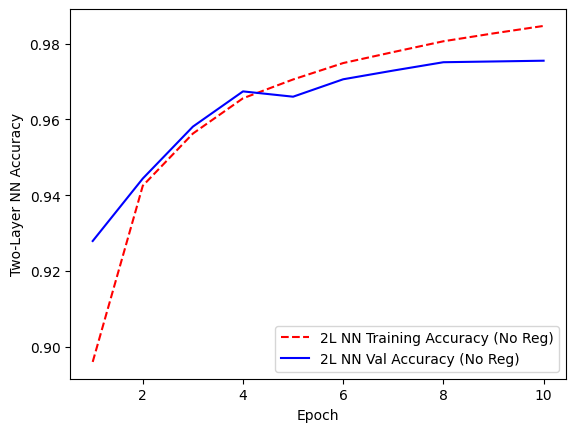

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9705 - loss: 0.0961
Validation Accuracy (No Regularization): 0.9754999876022339


In [ ]:
# Plot for 2.6: Regularizer (Default: None)
training_acc = nn_hist_noreg.history['accuracy']
val_acc = nn_hist_noreg.history['val_accuracy']

epoch_count = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['2L NN Training Accuracy (No Reg)', '2L NN Val Accuracy (No Reg)'])
plt.xlabel('Epoch')
plt.ylabel('Two-Layer NN Accuracy')
plt.show()

val_loss, val_acc = fc_model_noreg.evaluate(val_images, val_labels)
print('Validation Accuracy (No Regularization):', val_acc)

In [ ]:
# 2.7) Regularizer - L2 Regularization
fc_model_l2 = build_fc_model(activation_first='relu', activation_output='softmax',
                            regularizer=tf.keras.regularizers.l2(0.001))

fc_model_l2.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fc_model_l2.build((None, train_images.shape[1], train_images.shape[2], train_images.shape[3]))
fc_model_l2.summary()

BATCH_SIZE = 64
EPOCHS = 10

nn_hist_l2 = fc_model_l2.fit(train_images, train_labels, validation_data=(val_images, val_labels), batch_size=BATCH_SIZE, epochs=EPOCHS)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8377 - loss: 0.8109 - val_accuracy: 0.9329 - val_loss: 0.4105
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9367 - loss: 0.3883 - val_accuracy: 0.9493 - val_loss: 0.3155
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9547 - loss: 0.2964 - val_accuracy: 0.9596 - val_loss: 0.2578
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9625 - loss: 0.2437 - val_accuracy: 0.9654 - val_loss: 0.2195
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9661 - loss: 0.2128 - val_accuracy: 0.9694 - val_loss: 0.1904
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9701 - loss: 0.1840 - val_accuracy: 0.9690 - val_loss: 0.1786
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9752 - loss: 0.1626 - val_accuracy: 0.9720 - val_loss: 0.1621
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9773 - loss: 0.1496 - val_accuracy: 0.

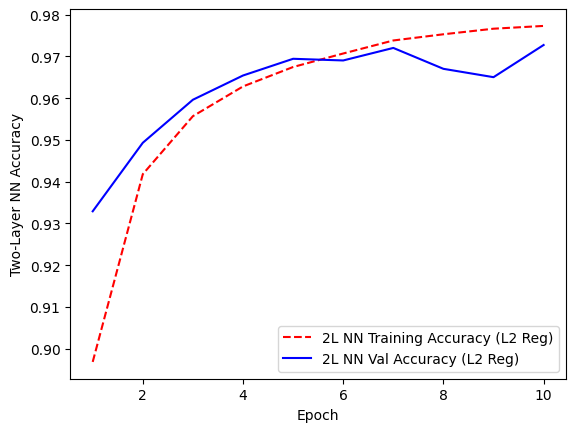

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9692 - loss: 0.1649
Validation Accuracy (L2 Regularization): 0.9726999998092651


In [ ]:
# Plot for 2.7: L2 Regularization
training_acc = nn_hist_l2.history['accuracy']
val_acc = nn_hist_l2.history['val_accuracy']

epoch_count = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['2L NN Training Accuracy (L2 Reg)', '2L NN Val Accuracy (L2 Reg)'])
plt.xlabel('Epoch')
plt.ylabel('Two-Layer NN Accuracy')
plt.show()

val_loss, val_acc = fc_model_l2.evaluate(val_images, val_labels)
print('Validation Accuracy (L2 Regularization):', val_acc)

In [ ]:
# 2.8) Regularizer - Dropout
def build_fc_model_with_dropout(activation_first='relu', activation_output='softmax', dropout_rate=0.3):
    fc_model = tf.keras.Sequential([
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation=activation_first),
        tf.keras.layers.Dropout(dropout_rate),  # Dropout layer after first dense
        tf.keras.layers.Dense(10, activation=activation_output)
    ])
    return fc_model

fc_model_dropout = build_fc_model_with_dropout(dropout_rate=0.3)

fc_model_dropout.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fc_model_dropout.build((None, train_images.shape[1], train_images.shape[2], train_images.shape[3]))
fc_model_dropout.summary()

BATCH_SIZE = 64
EPOCHS = 10

nn_hist_dropout = fc_model_dropout.fit(train_images, train_labels, validation_data=(val_images, val_labels), batch_size=BATCH_SIZE, epochs=EPOCHS)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7949 - loss: 0.6938 - val_accuracy: 0.9398 - val_loss: 0.2152
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9272 - loss: 0.2513 - val_accuracy: 0.9546 - val_loss: 0.1587
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9431 - loss: 0.1970 - val_accuracy: 0.9620 - val_loss: 0.1308
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9511 - loss: 0.1647 - val_accuracy: 0.9640 - val_loss: 0.1191
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9574 - loss: 0.1484 - val_accuracy: 0.9664 - val_loss: 0.1142
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9615 - loss: 0.1344 - val_accuracy: 0.9713 - val_loss: 0.0975
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9657 - loss: 0.1188 - val_accuracy: 0.9724 - val_loss: 0.0917
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9662 - loss: 0.1126 - val_accuracy: 0.

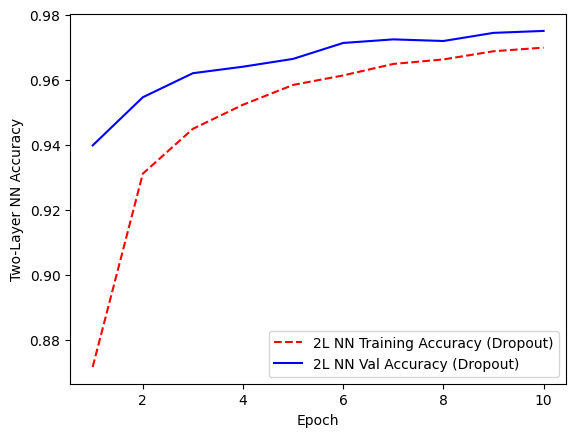

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9708 - loss: 0.0930
Validation Accuracy (Dropout): 0.9750000238418579


In [ ]:
# Plot for 2.8: Dropout
training_acc = nn_hist_dropout.history['accuracy']
val_acc = nn_hist_dropout.history['val_accuracy']

epoch_count = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['2L NN Training Accuracy (Dropout)', '2L NN Val Accuracy (Dropout)'])
plt.xlabel('Epoch')
plt.ylabel('Two-Layer NN Accuracy')
plt.show()

val_loss, val_acc = fc_model_dropout.evaluate(val_images, val_labels)
print('Validation Accuracy (Dropout):', val_acc)

In [ ]:
# 2.9) Optimizer - SGD with learning_rate=0.1
fc_model_sgd = build_fc_model(activation_first='relu', activation_output='softmax', regularizer=None)

fc_model_sgd.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fc_model_sgd.build((None, train_images.shape[1], train_images.shape[2], train_images.shape[3]))
fc_model_sgd.summary()

BATCH_SIZE = 64
EPOCHS = 10

nn_hist_sgd = fc_model_sgd.fit(train_images, train_labels, validation_data=(val_images, val_labels), batch_size=BATCH_SIZE, epochs=EPOCHS)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8413 - loss: 0.5727 - val_accuracy: 0.9290 - val_loss: 0.2392
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9392 - loss: 0.2166 - val_accuracy: 0.9492 - val_loss: 0.1729
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9550 - loss: 0.1546 - val_accuracy: 0.9595 - val_loss: 0.1350
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9628 - loss: 0.1292 - val_accuracy: 0.9652 - val_loss: 0.1176
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9701 - loss: 0.1063 - val_accuracy: 0.9654 - val_loss: 0.1146
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9737 - loss: 0.0901 - val_accuracy: 0.9691 - val_loss: 0.0976
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9773 - loss: 0.0785 - val_accuracy: 0.9720 - val_loss: 0.0907
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9803 - loss: 0.0707 - val_accuracy: 0.

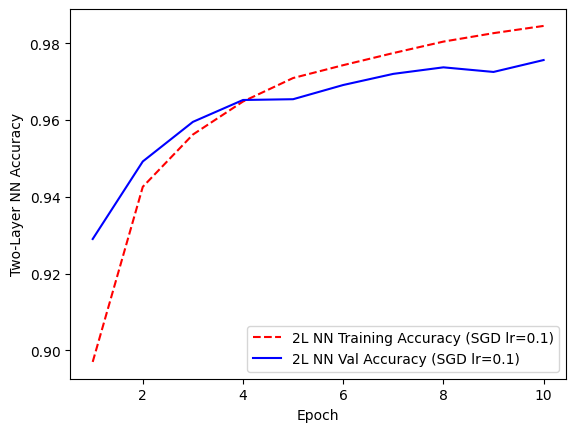

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9715 - loss: 0.0916
Validation Accuracy (SGD lr=0.1): 0.975600004196167


In [ ]:
# Plot for 2.9: SGD with learning_rate=0.1
training_acc = nn_hist_sgd.history['accuracy']
val_acc = nn_hist_sgd.history['val_accuracy']

epoch_count = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['2L NN Training Accuracy (SGD lr=0.1)', '2L NN Val Accuracy (SGD lr=0.1)'])
plt.xlabel('Epoch')
plt.ylabel('Two-Layer NN Accuracy')
plt.show()

val_loss, val_acc = fc_model_sgd.evaluate(val_images, val_labels)
print('Validation Accuracy (SGD lr=0.1):', val_acc)

In [ ]:
# 2.10) Optimizer - SGD with learning rate = 0.01
fc_model_sgd_low = build_fc_model(activation_first='relu', activation_output='softmax', regularizer=None)

fc_model_sgd_low.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),  # Lower learning rate
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fc_model_sgd_low.build((None, train_images.shape[1], train_images.shape[2], train_images.shape[3]))
fc_model_sgd_low.summary()

BATCH_SIZE = 64
EPOCHS = 10

nn_hist_sgd_low = fc_model_sgd_low.fit(train_images, train_labels, validation_data=(val_images, val_labels), batch_size=BATCH_SIZE, epochs=EPOCHS)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6392 - loss: 1.3660 - val_accuracy: 0.8858 - val_loss: 0.4631
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8824 - loss: 0.4493 - val_accuracy: 0.9064 - val_loss: 0.3550
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9007 - loss: 0.3625 - val_accuracy: 0.9134 - val_loss: 0.3165
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9097 - loss: 0.3252 - val_accuracy: 0.9194 - val_loss: 0.2918
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9175 - loss: 0.2984 - val_accuracy: 0.9246 - val_loss: 0.2725
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9227 - loss: 0.2776 - val_accuracy: 0.9283 - val_loss: 0.2584
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9253 - loss: 0.2662 - val_accuracy: 0.9301 - val_loss: 0.2479
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9284 - loss: 0.2576 - val_accuracy: 0.

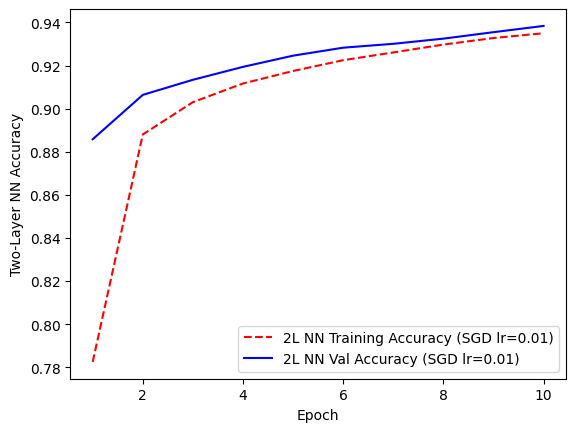

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9282 - loss: 0.2576
Validation Accuracy (SGD lr=0.01): 0.9383999705314636


In [ ]:
# Plot for 2.10: SGD with learning rate = 0.01
training_acc = nn_hist_sgd_low.history['accuracy']
val_acc = nn_hist_sgd_low.history['val_accuracy']

epoch_count = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['2L NN Training Accuracy (SGD lr=0.01)', '2L NN Val Accuracy (SGD lr=0.01)'])
plt.xlabel('Epoch')
plt.ylabel('Two-Layer NN Accuracy')
plt.show()

val_loss, val_acc = fc_model_sgd_low.evaluate(val_images, val_labels)
print('Validation Accuracy (SGD lr=0.01):', val_acc)

In [ ]:
# 2.11) Optimizer - ADAM
fc_model_adam = build_fc_model(activation_first='relu', activation_output='softmax', regularizer=None)

fc_model_adam.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fc_model_adam.build((None, train_images.shape[1], train_images.shape[2], train_images.shape[3]))
fc_model_adam.summary()

BATCH_SIZE = 64
EPOCHS = 10

nn_hist_adam = fc_model_adam.fit(train_images, train_labels, validation_data=(val_images, val_labels), batch_size=BATCH_SIZE, epochs=EPOCHS)

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8615 - loss: 0.5072 - val_accuracy: 0.9514 - val_loss: 0.1640
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9587 - loss: 0.1445 - val_accuracy: 0.9661 - val_loss: 0.1116
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9717 - loss: 0.0972 - val_accuracy: 0.9716 - val_loss: 0.0904
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9796 - loss: 0.0719 - val_accuracy: 0.9733 - val_loss: 0.0865
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9830 - loss: 0.0570 - val_accuracy: 0.9769 - val_loss: 0.0778
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9869 - loss: 0.0433 - val_accuracy: 0.9765 - val_loss: 0.0789
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9897 - loss: 0.0364 - val_accuracy: 0.9755 - val_loss: 0.0742
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9909 - loss: 0.0303 - val_accuracy: 0.

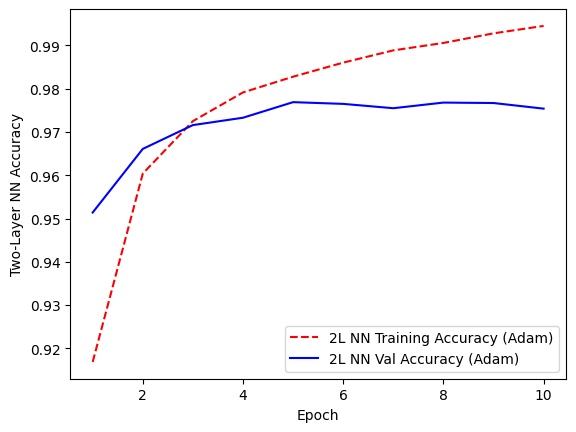

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9710 - loss: 0.0946
Validation Accuracy (Adam): 0.9753999710083008


In [ ]:
# Plot for 2.11: ADAM
training_acc = nn_hist_adam.history['accuracy']
val_acc = nn_hist_adam.history['val_accuracy']

epoch_count = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['2L NN Training Accuracy (Adam)', '2L NN Val Accuracy (Adam)'])
plt.xlabel('Epoch')
plt.ylabel('Two-Layer NN Accuracy')
plt.show()

val_loss, val_acc = fc_model_adam.evaluate(val_images, val_labels)
print('Validation Accuracy (Adam):', val_acc)

In [ ]:
# 2.12) Optimizer - RMSprop
fc_model_rmsprop = build_fc_model(activation_first='relu', activation_output='softmax', regularizer=None)

fc_model_rmsprop.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fc_model_rmsprop.build((None, train_images.shape[1], train_images.shape[2], train_images.shape[3]))
fc_model_rmsprop.summary()

BATCH_SIZE = 64
EPOCHS = 10

nn_hist_rmsprop = fc_model_rmsprop.fit(train_images, train_labels, validation_data=(val_images, val_labels), batch_size=BATCH_SIZE, epochs=EPOCHS)

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8773 - loss: 0.4607 - val_accuracy: 0.9560 - val_loss: 0.1547
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9569 - loss: 0.1489 - val_accuracy: 0.9658 - val_loss: 0.1128
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9716 - loss: 0.0960 - val_accuracy: 0.9667 - val_loss: 0.1089
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9782 - loss: 0.0728 - val_accuracy: 0.9745 - val_loss: 0.0860
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9825 - loss: 0.0595 - val_accuracy: 0.9774 - val_loss: 0.0770
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9854 - loss: 0.0501 - val_accuracy: 0.9795 - val_loss: 0.0692
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9883 - loss: 0.0402 - val_accuracy: 0.9797 - val_loss: 0.0694
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9894 - loss: 0.0350 - val_accuracy: 0.

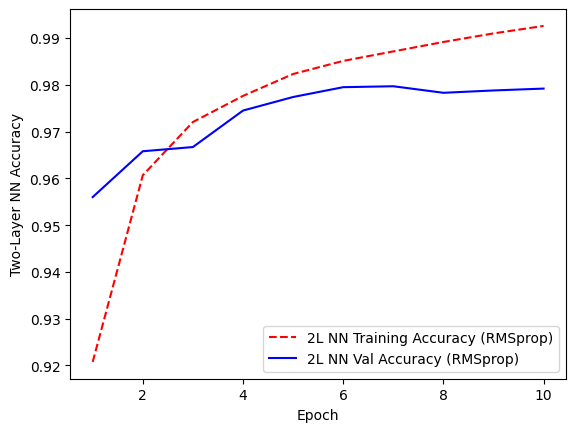

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9741 - loss: 0.0882
Validation Accuracy (RMSprop): 0.979200005531311


In [ ]:
# Plot for 2.12: RMSprop
training_acc = nn_hist_rmsprop.history['accuracy']
val_acc = nn_hist_rmsprop.history['val_accuracy']

epoch_count = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['2L NN Training Accuracy (RMSprop)', '2L NN Val Accuracy (RMSprop)'])
plt.xlabel('Epoch')
plt.ylabel('Two-Layer NN Accuracy')
plt.show()

val_loss, val_acc = fc_model_rmsprop.evaluate(val_images, val_labels)
print('Validation Accuracy (RMSprop):', val_acc)

In [ ]:
# 2.13) Loss (Default: Crossentropy)
fc_model_ce = build_fc_model(activation_first='relu', activation_output='softmax', regularizer=None)

fc_model_ce.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fc_model_ce.build((None, train_images.shape[1], train_images.shape[2], train_images.shape[3]))
fc_model_ce.summary()

BATCH_SIZE = 64
EPOCHS = 10

nn_hist_ce = fc_model_ce.fit(train_images, train_labels_onehot, validation_data=(val_images, val_labels_onehot), batch_size=BATCH_SIZE, epochs=EPOCHS)

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_11 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8609 - loss: 0.4975 - val_accuracy: 0.9496 - val_loss: 0.1721
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9575 - loss: 0.1477 - val_accuracy: 0.9635 - val_loss: 0.1196
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9722 - loss: 0.0972 - val_accuracy: 0.9722 - val_loss: 0.0923
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9793 - loss: 0.0731 - val_accuracy: 0.9736 - val_loss: 0.0851
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9839 - loss: 0.0561 - val_accuracy: 0.9749 - val_loss: 0.0819
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9863 - loss: 0.0462 - val_accuracy: 0.9764 - val_loss: 0.0768
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9898 - loss: 0.0356 - val_accuracy: 0.9758 - val_loss: 0.0790
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9919 - loss: 0.0300 - val_accuracy: 0.

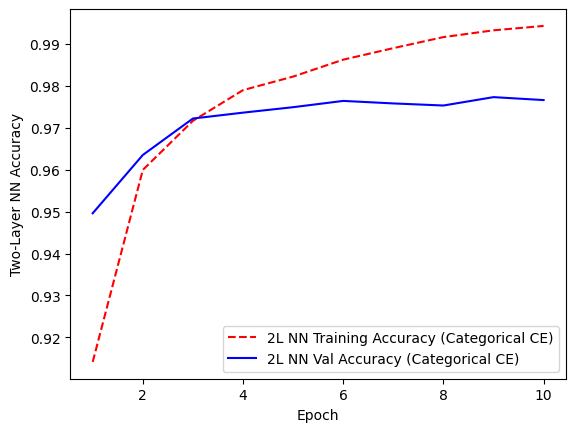

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9746 - loss: 0.0817
Validation Accuracy (Categorical Crossentropy): 0.9765999913215637


In [ ]:
# Plot for 2.13: Loss (Default: Crossentropy)
training_acc = nn_hist_ce.history['accuracy']
val_acc = nn_hist_ce.history['val_accuracy']

epoch_count = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['2L NN Training Accuracy (Categorical CE)', '2L NN Val Accuracy (Categorical CE)'])
plt.xlabel('Epoch')
plt.ylabel('Two-Layer NN Accuracy')
plt.show()

val_loss, val_acc = fc_model_ce.evaluate(val_images, val_labels_onehot)
print('Validation Accuracy (Categorical Crossentropy):', val_acc)

In [ ]:
# 2.14) Loss - Mean Squared Error (MSE)
fc_model_mse = build_fc_model(activation_first='relu', activation_output='softmax', regularizer=None)

fc_model_mse.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['accuracy']
)

fc_model_mse.build((None, train_images.shape[1], train_images.shape[2], train_images.shape[3]))
fc_model_mse.summary()

BATCH_SIZE = 64
EPOCHS = 10

nn_hist_mse = fc_model_mse.fit(train_images, train_labels_onehot, validation_data=(val_images, val_labels_onehot), batch_size=BATCH_SIZE, epochs=EPOCHS)

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_12 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8519 - loss: 0.0221 - val_accuracy: 0.9508 - val_loss: 0.0077
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9583 - loss: 0.0066 - val_accuracy: 0.9622 - val_loss: 0.0061
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9709 - loss: 0.0048 - val_accuracy: 0.9703 - val_loss: 0.0046
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9774 - loss: 0.0037 - val_accuracy: 0.9710 - val_loss: 0.0045
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9829 - loss: 0.0029 - val_accuracy: 0.9745 - val_loss: 0.0040
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9857 - loss: 0.0025 - val_accuracy: 0.9776 - val_loss: 0.0036
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9874 - loss: 0.0022 - val_accuracy: 0.9757 - val_loss: 0.0037
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9898 - loss: 0.0019 - val_accuracy: 0.

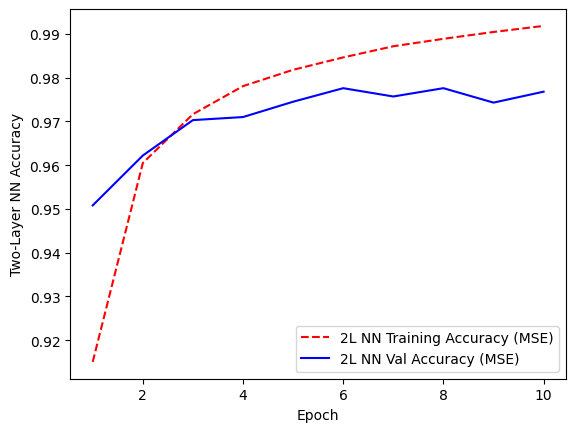

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9729 - loss: 0.0043
Validation Accuracy (MSE): 0.9768000245094299


In [ ]:
# Plot for 2.14: Mean Squared Error (MSE)
training_acc = nn_hist_mse.history['accuracy']
val_acc = nn_hist_mse.history['val_accuracy']

epoch_count = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['2L NN Training Accuracy (MSE)', '2L NN Val Accuracy (MSE)'])
plt.xlabel('Epoch')
plt.ylabel('Two-Layer NN Accuracy')
plt.show()

val_loss, val_acc = fc_model_mse.evaluate(val_images, val_labels_onehot)
print('Validation Accuracy (MSE):', val_acc)

In [ ]:
# 2.15) Loss - Sparse Categorical Crossentropy
fc_model_sparse = build_fc_model(activation_first='relu', activation_output='softmax', regularizer=None)

fc_model_sparse.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

fc_model_sparse.build((None, train_images.shape[1], train_images.shape[2], train_images.shape[3]))
fc_model_sparse.summary()

BATCH_SIZE = 64
EPOCHS = 10

nn_hist_sparse = fc_model_sparse.fit(train_images, train_labels, validation_data=(val_images, val_labels), batch_size=BATCH_SIZE, epochs=EPOCHS)

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_13 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8560 - loss: 0.5139 - val_accuracy: 0.9505 - val_loss: 0.1716
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9570 - loss: 0.1509 - val_accuracy: 0.9650 - val_loss: 0.1148
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9724 - loss: 0.0980 - val_accuracy: 0.9712 - val_loss: 0.0983
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9784 - loss: 0.0743 - val_accuracy: 0.9728 - val_loss: 0.0867
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9832 - loss: 0.0590 - val_accuracy: 0.9757 - val_loss: 0.0837
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9849 - loss: 0.0486 - val_accuracy: 0.9776 - val_loss: 0.0763
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9901 - loss: 0.0348 - val_accuracy: 0.9744 - val_loss: 0.0854
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9911 - loss: 0.0298 - val_accuracy: 0.

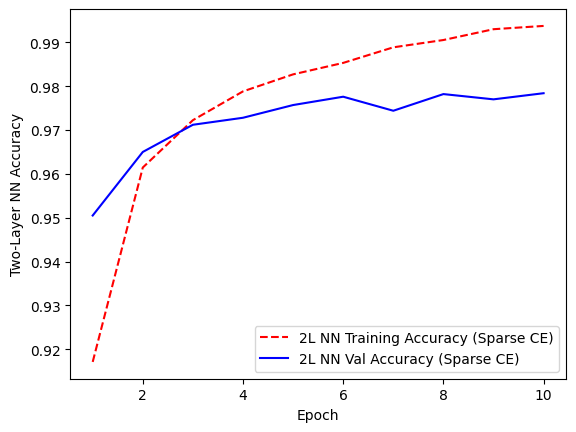

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9755 - loss: 0.0894
Validation Accuracy (Sparse Categorical Crossentropy): 0.9783999919891357


In [ ]:
# Plot for 2.15: Sparse Categorical Crossentropy
training_acc = nn_hist_sparse.history['accuracy']
val_acc = nn_hist_sparse.history['val_accuracy']

epoch_count = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['2L NN Training Accuracy (Sparse CE)', '2L NN Val Accuracy (Sparse CE)'])
plt.xlabel('Epoch')
plt.ylabel('Two-Layer NN Accuracy')
plt.show()

val_loss, val_acc = fc_model_sparse.evaluate(val_images, val_labels)
print('Validation Accuracy (Sparse Categorical Crossentropy):', val_acc)

### 1.2.3 Convolutional Neural Network Solution

**IMPORTANT NOTE:** You have to change runtime type on Google Colab to GPU when training the model of this part since CNN models require much computation resources and it will run very slowly on CPU (Default runtime type)

Click on "Runtime" => "Change runtime type" => make sure that GPU is selected in the "Hardware accelerator"

Build a CNN, using tf.keras, composed of two convolutional layers and pooling layers, followed by two fully connected layers, and ultimately output a probability distribution over the 10 digit classes (0-9).

![CNN Model](https://github.com/KhaledElTahan/DeepLearning/blob/master/Labs/lab2/cnn_model.png?raw=1)

#### Define the Convolutional Neural Network

**TODO**

1. Define the convolutional network exactly as in the previous figure by adding [Conv2D layers](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D), [MaxPool2D layers](https://www.tensorflow.org/api_docs/python/tf/keras/layers/MaxPool2D), [flatten layer](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Flatten), and [dense layers](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense)
2. Try different [activation functions](https://keras.io/api/layers/#layer-activations) for the layers (ReLU, Tanh, and other activations for hidden layers - Softmax, and other activations for output layer), and report the difference in **accuracy** and plots.
3. Try different [regularization kernerls](https://keras.io/api/layers/#layer-weight-regularizers), and [regularization layers](https://keras.io/api/layers/#regularization-layers) (L1, L2, Dropout, and other regularizations), and report the difference in **accuracy** and plots.
4. Try different [convolution filter sizes](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D), and report the difference in accuracy and plots.
5. **For each convolution filter size**, try different stride lengths, and report the difference in accuracy and plots.
6. Try different [pooling layers](https://keras.io/api/layers/pooling_layers/) (i.e. change first and second pooling layers into other different pooling layers), and report the difference in accuracy and plots.

**NOTE: Variations for the filter sizes, stride lengths and pooling layers, will mean of course that you will have to use different number of units for the next layers (i.e. you won't stick to the above mentioned figure once you try those variations).**

**Make sure to add the following to the report:**


*   Include the default cases for the activation function of the hidden layers using ReLU (3.1 in the report)
*   Try out one different activation functions for the hidden layers and include it (3.2 in the report)
*   Include the default case for the activation function of the output layer using Softmax (3.3 in the report)
*   Try out another activation function for the output layer (3.4 in the report)
*   Include the default case where no regularization is added (3.5 in the report)
*   Experiment with two different regularization approaches (3.6 and 3.7 in the report)
*   Include the default case where the filter size is 3x3 and the stride length is 1 (3.8 in the report)
*   Experiment with other combinations of filter sizes and stride lengths (3.9, 3.10, 3.11, 3.12 in the report)
*   Include the default case where two max pool layers are used (3.13 in the report)
*   Experiment with other combinations of pooling layers (3.14, 3.15 in the report)



In [ ]:
def build_cnn_model(activation_hidden='relu', activation_output='softmax',
                   regularizer=None, filter1_size=3, filter2_size=3,
                   stride1=1, stride2=1, pool1_size=2, pool2_size=2,
                   pool1_type='max', pool2_type='max'):

    cnn_model = tf.keras.Sequential([
        # 1st convolutional layer
        tf.keras.layers.Conv2D(filters=32, kernel_size=(filter1_size, filter1_size),
                              strides=stride1, input_shape=(28,28,1),
                              activation=activation_hidden,
                              kernel_regularizer=regularizer),

        # 1st pooling layer
        tf.keras.layers.MaxPool2D(pool_size=(pool1_size, pool1_size)) if pool1_type == 'max' else
        tf.keras.layers.AveragePooling2D(pool_size=(pool1_size, pool1_size)),

        # 2nd convolutional layer
        tf.keras.layers.Conv2D(filters=64, kernel_size=(filter2_size, filter2_size),
                              strides=stride2, activation=activation_hidden,
                              kernel_regularizer=regularizer),

        # 2nd pooling layer
        tf.keras.layers.MaxPool2D(pool_size=(pool2_size, pool2_size)) if pool2_type == 'max' else
        tf.keras.layers.AveragePooling2D(pool_size=(pool2_size, pool2_size)),

        # Flatten layer
        tf.keras.layers.Flatten(),

        # 1st dense layer
        tf.keras.layers.Dense(900, activation=activation_hidden,
                             kernel_regularizer=regularizer),

        # Output layer
        tf.keras.layers.Dense(10, activation=activation_output)
    ])
    return cnn_model

#### Compile the Convolutional Neural Network

**TODO**

1. Try different [optimizers](https://keras.io/api/optimizers/), and report the difference in **accuracy** and plots.
2. **For each optimizer**, try different learning rates and other hyperparameters (If applicable), and report the difference in **accuracy** and plots.
3. Try different [loss functions](https://keras.io/api/losses/), and report the difference in **accuracy** and plots.

**Make sure to add the following to the report:**


*   Include the default case for the optimizer and its hyperparameters using SGD(lr = 0.1) (3.16 in the report)
*   Experiment with other combinations of optimizers and their hyperparameters (3.17, 3.18, 3.19 in the report)
*   Include the default case for the loss using cross entropy (3.20 in the report)
*   Try out two other loss functions (3.21, 3.22 in the report)



In [ ]:
# 3.1) Activation Function Hidden Layers - 1: ReLU (Default)
cnn_model_baseline = build_cnn_model(activation_hidden='relu', activation_output='softmax')

cnn_model_baseline.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model_baseline.build((None, train_images.shape[1], train_images.shape[2], train_images.shape[3]))
cnn_model_baseline.summary()

BATCH_SIZE = 64
EPOCHS = 20

cnn_hist_baseline = cnn_model_baseline.fit(train_images, train_labels, validation_data=(val_images, val_labels), batch_size=BATCH_SIZE, epochs=EPOCHS)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 900)            │     1,440,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │         9,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,468,726 (5.60 MB)

 Trainable params: 1,468,726 (5.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 59s 63ms/step - accuracy: 0.8405 - loss: 0.5093 - val_accuracy: 0.9709 - val_loss: 0.0912
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 60s 64ms/step - accuracy: 0.9786 - loss: 0.0676 - val_accuracy: 0.9863 - val_loss: 0.0418
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 84s 66ms/step - accuracy: 0.9865 - loss: 0.0436 - val_accuracy: 0.9879 - val_loss: 0.0360
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 65ms/step - accuracy: 0.9895 - loss: 0.0328 - val_accuracy: 0.9872 - val_loss: 0.0384
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 65ms/step - accuracy: 0.9924 - loss: 0.0251 - val_accuracy: 0.9895 - val_loss: 0.0353
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 61s 65ms/step - accuracy: 0.9943 - loss: 0.0188 - val_accuracy: 0.9885 - val_loss: 0.0330
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 83s 65ms/step - accuracy: 0.9947 - loss: 0.0165 - val_accuracy: 0.9902 - val_loss: 0.0322
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 66ms/step - accuracy: 0.9964 - loss: 0.0115 - 

# #### Print the Convolutional Neural Network Model Summary

In [ ]:
cnn_model_baseline.build((None, train_images.shape[1], train_images.shape[2], train_images.shape[3]))
cnn_model_baseline.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 900)            │     1,440,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 10)             │         9,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,468,728 (5.60 MB)

 Trainable params: 1,468,726 (5.60 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

#### Train the Convolutional Neural Network

In [ ]:
BATCH_SIZE = 64
EPOCHS = 20

cnn_hist = cnn_model_baseline.fit(train_images, train_labels, validation_data=(val_images, val_labels), batch_size=BATCH_SIZE, epochs=EPOCHS)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 72s 77ms/step - accuracy: 1.0000 - loss: 3.2107e-04 - val_accuracy: 0.9913 - val_loss: 0.0341
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 59s 63ms/step - accuracy: 1.0000 - loss: 2.0234e-04 - val_accuracy: 0.9914 - val_loss: 0.0342
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 83s 65ms/step - accuracy: 1.0000 - loss: 1.8379e-04 - val_accuracy: 0.9916 - val_loss: 0.0346
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 83s 66ms/step - accuracy: 1.0000 - loss: 1.9558e-04 - val_accuracy: 0.9916 - val_loss: 0.0354
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 60s 64ms/step - accuracy: 1.0000 - loss: 1.5355e-04 - val_accuracy: 0.9914 - val_loss: 0.0355
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 61s 65ms/step - accuracy: 1.0000 - loss: 1.3771e-04 - val_accuracy: 0.9914 - val_loss: 0.0354
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 63s 67ms/step - accuracy: 1.0000 - loss: 1.1813e-04 - val_accuracy: 0.9914 - val_loss: 0.0361
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 66ms/step - accura

#### Plot the Accuracy Curve for the Convolutional Neural Network

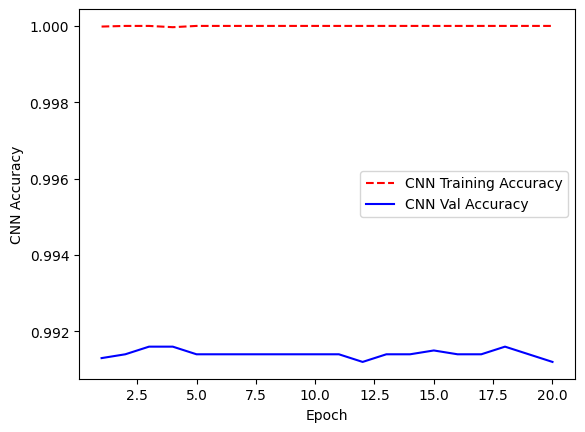

In [ ]:
# Get training and validation accuracy histories
training_acc = cnn_hist.history['accuracy']
val_acc = cnn_hist.history['val_accuracy']

# Create count of the number of epochs
epoch_count = range(1, EPOCHS + 1)

# Visualize accuracy history
plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['CNN Training Accuracy', 'CNN Val Accuracy'])
plt.xlabel('Epoch')
plt.ylabel('CNN Accuracy')
plt.show()

#### Evaluate the Convolutional Neural Network

In [ ]:
val_loss, val_acc = cnn_model_baseline.evaluate(val_images, val_labels)

print('Validation Accuracy:', val_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9882 - loss: 0.0534
Validation Accuracy: 0.9911999702453613


In [ ]:
# 3.2) Activation Function Hidden Layers - Tanh
cnn_model_tanh = build_cnn_model(activation_hidden='tanh', activation_output='softmax')

cnn_model_tanh.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model_tanh.build((None, train_images.shape[1], train_images.shape[2], train_images.shape[3]))
cnn_model_tanh.summary()

BATCH_SIZE = 64
EPOCHS = 20

cnn_hist_tanh = cnn_model_tanh.fit(train_images, train_labels, validation_data=(val_images, val_labels), batch_size=BATCH_SIZE, epochs=EPOCHS)

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 900)            │     1,440,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 10)             │         9,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,468,726 (5.60 MB)

 Trainable params: 1,468,726 (5.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 63s 66ms/step - accuracy: 0.8689 - loss: 0.4313 - val_accuracy: 0.9713 - val_loss: 0.0932
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 66ms/step - accuracy: 0.9783 - loss: 0.0717 - val_accuracy: 0.9850 - val_loss: 0.0494
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 84s 68ms/step - accuracy: 0.9845 - loss: 0.0517 - val_accuracy: 0.9853 - val_loss: 0.0431
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 62s 66ms/step - accuracy: 0.9881 - loss: 0.0392 - val_accuracy: 0.9874 - val_loss: 0.0387
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 67ms/step - accuracy: 0.9912 - loss: 0.0305 - val_accuracy: 0.9889 - val_loss: 0.0359
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 83s 68ms/step - accuracy: 0.9925 - loss: 0.0257 - val_accuracy: 0.9865 - val_loss: 0.0436
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 63s 67ms/step - accuracy: 0.9945 - loss: 0.0195 - val_accuracy: 0.9898 - val_loss: 0.0335
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 67ms/step - accuracy: 0.9962 - loss: 0.0143 - 

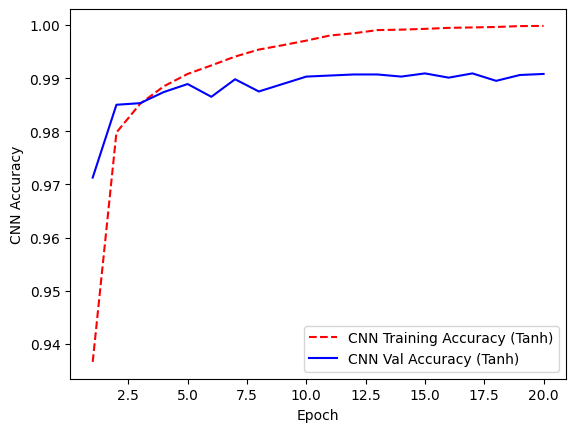

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9880 - loss: 0.0410
Validation Accuracy (Tanh Hidden): 0.9908000230789185


In [ ]:
# Plot for 3.2: Tanh
training_acc = cnn_hist_tanh.history['accuracy']
val_acc = cnn_hist_tanh.history['val_accuracy']

epoch_count = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['CNN Training Accuracy (Tanh)', 'CNN Val Accuracy (Tanh)'])
plt.xlabel('Epoch')
plt.ylabel('CNN Accuracy')
plt.show()

val_loss, val_acc = cnn_model_tanh.evaluate(val_images, val_labels)
print('Validation Accuracy (Tanh Hidden):', val_acc)

In [ ]:
# 3.4) Activation Function Output Layer - Linear
cnn_model_linear_out = build_cnn_model(activation_hidden='relu', activation_output='linear')

cnn_model_linear_out.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model_linear_out.build((None, train_images.shape[1], train_images.shape[2], train_images.shape[3]))
cnn_model_linear_out.summary()

BATCH_SIZE = 64
EPOCHS = 20

cnn_hist_linear_out = cnn_model_linear_out.fit(train_images, train_labels, validation_data=(val_images, val_labels), batch_size=BATCH_SIZE, epochs=EPOCHS)

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 900)            │     1,440,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 10)             │         9,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,468,726 (5.60 MB)

 Trainable params: 1,468,726 (5.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 65s 68ms/step - accuracy: 0.0920 - loss: 8.5020 - val_accuracy: 0.0892 - val_loss: 8.4888
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 62s 66ms/step - accuracy: 0.0888 - loss: 8.5175 - val_accuracy: 0.0892 - val_loss: 8.4888
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 65ms/step - accuracy: 0.0898 - loss: 8.4985 - val_accuracy: 0.0892 - val_loss: 8.4888
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 63s 68ms/step - accuracy: 0.0911 - loss: 8.4907 - val_accuracy: 0.0892 - val_loss: 8.4888
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 62s 66ms/step - accuracy: 0.0906 - loss: 8.5122 - val_accuracy: 0.0892 - val_loss: 8.4888
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 63s 67ms/step - accuracy: 0.0888 - loss: 8.5079 - val_accuracy: 0.0892 - val_loss: 8.4888
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 67ms/step - accuracy: 0.0906 - loss: 8.4736 - val_accuracy: 0.0892 - val_loss: 8.4888
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 62s 67ms/step - accuracy: 0.0896 - loss: 8.4818 - 

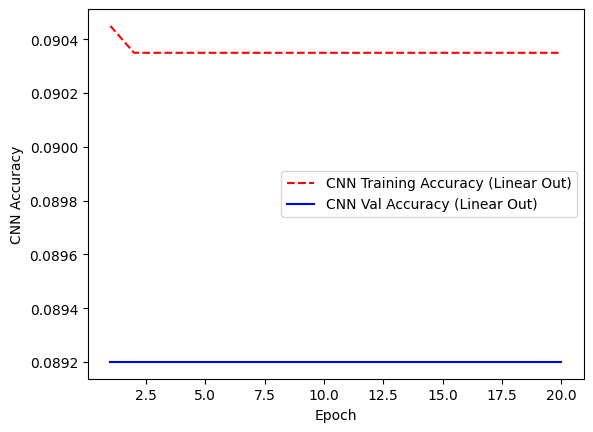

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.0912 - loss: 8.6276
Validation Accuracy (Linear Output): 0.08919999748468399


In [ ]:
# Plot for 3.4: Linear
training_acc = cnn_hist_linear_out.history['accuracy']
val_acc = cnn_hist_linear_out.history['val_accuracy']

epoch_count = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['CNN Training Accuracy (Linear Out)', 'CNN Val Accuracy (Linear Out)'])
plt.xlabel('Epoch')
plt.ylabel('CNN Accuracy')
plt.show()

val_loss, val_acc = cnn_model_linear_out.evaluate(val_images, val_labels)
print('Validation Accuracy (Linear Output):', val_acc)

In [ ]:
# 3.6) Regularizer - L2 Regularization
cnn_model_l2 = build_cnn_model(activation_hidden='relu', activation_output='softmax',
                              regularizer=tf.keras.regularizers.l2(0.001))

cnn_model_l2.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model_l2.build((None, train_images.shape[1], train_images.shape[2], train_images.shape[3]))
cnn_model_l2.summary()

BATCH_SIZE = 64
EPOCHS = 20

cnn_hist_l2 = cnn_model_l2.fit(train_images, train_labels, validation_data=(val_images, val_labels), batch_size=BATCH_SIZE, epochs=EPOCHS)

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 900)            │     1,440,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 10)             │         9,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,468,726 (5.60 MB)

 Trainable params: 1,468,726 (5.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 66s 70ms/step - accuracy: 0.8393 - loss: 1.6268 - val_accuracy: 0.9781 - val_loss: 0.9235
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 83s 71ms/step - accuracy: 0.9781 - loss: 0.8589 - val_accuracy: 0.9794 - val_loss: 0.6628
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 68s 72ms/step - accuracy: 0.9836 - loss: 0.6101 - val_accuracy: 0.9859 - val_loss: 0.4727
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 68s 72ms/step - accuracy: 0.9866 - loss: 0.4428 - val_accuracy: 0.9884 - val_loss: 0.3460
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 83s 73ms/step - accuracy: 0.9887 - loss: 0.3258 - val_accuracy: 0.9875 - val_loss: 0.2679
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 68s 72ms/step - accuracy: 0.9895 - loss: 0.2476 - val_accuracy: 0.9714 - val_loss: 0.2580
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 67s 72ms/step - accuracy: 0.9909 - loss: 0.1923 - val_accuracy: 0.9860 - val_loss: 0.1743
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 72ms/step - accuracy: 0.9902 - loss: 0.1557 - 

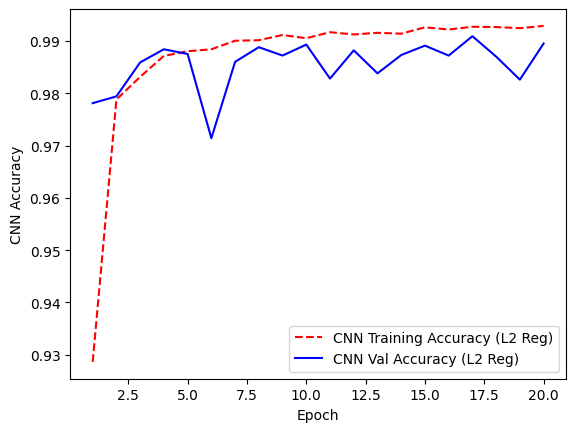

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9868 - loss: 0.0816
Validation Accuracy (L2 Regularization): 0.9894999861717224


In [ ]:
# Plot for 3.6: L2 Regularization
training_acc = cnn_hist_l2.history['accuracy']
val_acc = cnn_hist_l2.history['val_accuracy']

epoch_count = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['CNN Training Accuracy (L2 Reg)', 'CNN Val Accuracy (L2 Reg)'])
plt.xlabel('Epoch')
plt.ylabel('CNN Accuracy')
plt.show()

val_loss, val_acc = cnn_model_l2.evaluate(val_images, val_labels)
print('Validation Accuracy (L2 Regularization):', val_acc)

In [ ]:
# 3.7) Regularizer - Dropout
def build_cnn_model_with_dropout(activation_hidden='relu', activation_output='softmax',
                                dropout_rate=0.3):
    cnn_model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation=activation_hidden, input_shape=(28,28,1)),
        tf.keras.layers.MaxPool2D((2,2)),
        tf.keras.layers.Dropout(dropout_rate),

        tf.keras.layers.Conv2D(64, (3,3), activation=activation_hidden),
        tf.keras.layers.MaxPool2D((2,2)),
        tf.keras.layers.Dropout(dropout_rate),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(900, activation=activation_hidden),
        tf.keras.layers.Dropout(dropout_rate),
        tf.keras.layers.Dense(10, activation=activation_output)
    ])
    return cnn_model

cnn_model_dropout = build_cnn_model_with_dropout(dropout_rate=0.3)

cnn_model_dropout.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model_dropout.build((None, train_images.shape[1], train_images.shape[2], train_images.shape[3]))
cnn_model_dropout.summary()

BATCH_SIZE = 64
EPOCHS = 20

cnn_hist_dropout = cnn_model_dropout.fit(train_images, train_labels, validation_data=(val_images, val_labels), batch_size=BATCH_SIZE, epochs=EPOCHS)

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_18 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 900)            │     1,440,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 900)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │         9,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,468,726 (5.60 MB)

 Trainable params: 1,468,726 (5.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 69s 72ms/step - accuracy: 0.7874 - loss: 0.6386 - val_accuracy: 0.9737 - val_loss: 0.0830
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 79s 69ms/step - accuracy: 0.9639 - loss: 0.1173 - val_accuracy: 0.9843 - val_loss: 0.0486
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 69ms/step - accuracy: 0.9739 - loss: 0.0835 - val_accuracy: 0.9870 - val_loss: 0.0395
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 65s 69ms/step - accuracy: 0.9797 - loss: 0.0686 - val_accuracy: 0.9893 - val_loss: 0.0324
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 65s 69ms/step - accuracy: 0.9831 - loss: 0.0534 - val_accuracy: 0.9895 - val_loss: 0.0319
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 67s 71ms/step - accuracy: 0.9840 - loss: 0.0499 - val_accuracy: 0.9893 - val_loss: 0.0289
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 64s 68ms/step - accuracy: 0.9871 - loss: 0.0423 - val_accuracy: 0.9916 - val_loss: 0.0272
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 83s 70ms/step - accuracy: 0.9857 - loss: 0.0438 - 

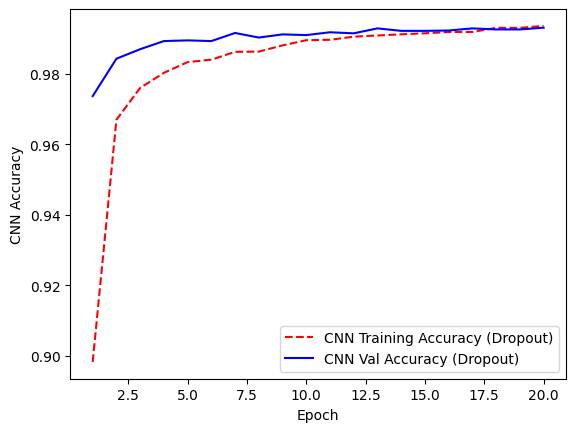

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9911 - loss: 0.0281
Validation Accuracy (Dropout): 0.9930999875068665


In [ ]:
# Plot for 3.7: Dropout
training_acc = cnn_hist_dropout.history['accuracy']
val_acc = cnn_hist_dropout.history['val_accuracy']

epoch_count = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['CNN Training Accuracy (Dropout)', 'CNN Val Accuracy (Dropout)'])
plt.xlabel('Epoch')
plt.ylabel('CNN Accuracy')
plt.show()

val_loss, val_acc = cnn_model_dropout.evaluate(val_images, val_labels)
print('Validation Accuracy (Dropout):', val_acc)

In [ ]:
# 3.9) Filter Size (Stride Length) - 3x3 (Stride=2)
cnn_model_stride2 = build_cnn_model(activation_hidden='relu', activation_output='softmax',
                                   filter1_size=3, filter2_size=3,
                                   stride1=2, stride2=1)  # Only stride first layer to see effect

cnn_model_stride2.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model_stride2.build((None, train_images.shape[1], train_images.shape[2], train_images.shape[3]))
cnn_model_stride2.summary()

BATCH_SIZE = 64
EPOCHS = 20

cnn_hist_stride2 = cnn_model_stride2.fit(train_images, train_labels, validation_data=(val_images, val_labels), batch_size=BATCH_SIZE, epochs=EPOCHS)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 13, 13, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_19 (Flatten)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 900)            │       231,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 10)             │         9,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 259,126 (1012.21 KB)

 Trainable params: 259,126 (1012.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.7218 - loss: 0.8690 - val_accuracy: 0.9266 - val_loss: 0.2071
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.9591 - loss: 0.1276 - val_accuracy: 0.9687 - val_loss: 0.0925
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.9752 - loss: 0.0789 - val_accuracy: 0.9708 - val_loss: 0.0870
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.9807 - loss: 0.0605 - val_accuracy: 0.9779 - val_loss: 0.0666
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.9846 - loss: 0.0475 - val_accuracy: 0.9782 - val_loss: 0.0666
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 17ms/step - accuracy: 0.9870 - loss: 0.0406 - val_accuracy: 0.9862 - val_loss: 0.0430
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.9885 - loss: 0.0350 - val_accuracy: 0.9867 - val_loss: 0.0382
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 15ms/step - accuracy: 0.9915 - loss: 0.0268 - 

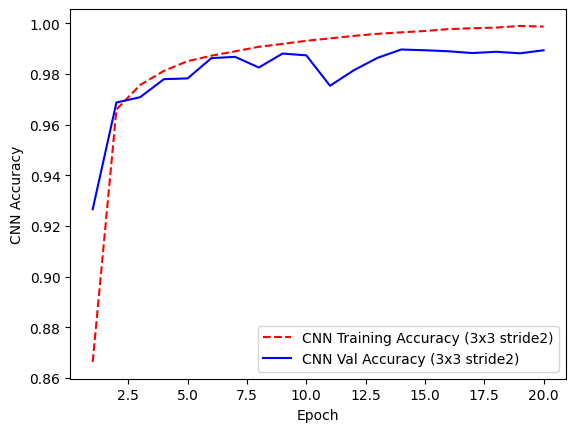

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9854 - loss: 0.0480
Validation Accuracy (3x3 filter, stride=2): 0.989300012588501


In [ ]:
# Plot for 3.9: 3x3 filter with Stride=2
training_acc = cnn_hist_stride2.history['accuracy']
val_acc = cnn_hist_stride2.history['val_accuracy']

epoch_count = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['CNN Training Accuracy (3x3 stride2)', 'CNN Val Accuracy (3x3 stride2)'])
plt.xlabel('Epoch')
plt.ylabel('CNN Accuracy')
plt.show()

val_loss, val_acc = cnn_model_stride2.evaluate(val_images, val_labels)
print('Validation Accuracy (3x3 filter, stride=2):', val_acc)

In [ ]:
# 3.10) Filter Size (Stride Length) - 5x5 (Stride=1)
cnn_model_5x5 = build_cnn_model(activation_hidden='relu', activation_output='softmax',
                               filter1_size=5, filter2_size=5,
                               stride1=1, stride2=1)

cnn_model_5x5.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model_5x5.build((None, train_images.shape[1], train_images.shape[2], train_images.shape[3]))
cnn_model_5x5.summary()

BATCH_SIZE = 64
EPOCHS = 20

cnn_hist_5x5 = cnn_model_5x5.fit(train_images, train_labels, validation_data=(val_images, val_labels), batch_size=BATCH_SIZE, epochs=EPOCHS)

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 24, 24, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 64)       │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 900)            │       922,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 10)             │         9,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 983,606 (3.75 MB)

 Trainable params: 983,606 (3.75 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 72s 77ms/step - accuracy: 0.8533 - loss: 0.4651 - val_accuracy: 0.9817 - val_loss: 0.0612
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 77s 83ms/step - accuracy: 0.9819 - loss: 0.0593 - val_accuracy: 0.9885 - val_loss: 0.0348
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 70s 74ms/step - accuracy: 0.9890 - loss: 0.0359 - val_accuracy: 0.9898 - val_loss: 0.0322
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 84s 76ms/step - accuracy: 0.9919 - loss: 0.0259 - val_accuracy: 0.9889 - val_loss: 0.0333
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 79s 73ms/step - accuracy: 0.9943 - loss: 0.0187 - val_accuracy: 0.9903 - val_loss: 0.0300
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 73ms/step - accuracy: 0.9953 - loss: 0.0156 - val_accuracy: 0.9910 - val_loss: 0.0282
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 80s 71ms/step - accuracy: 0.9973 - loss: 0.0103 - val_accuracy: 0.9899 - val_loss: 0.0345
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 69s 74ms/step - accuracy: 0.9971 - loss: 0.0093 - 

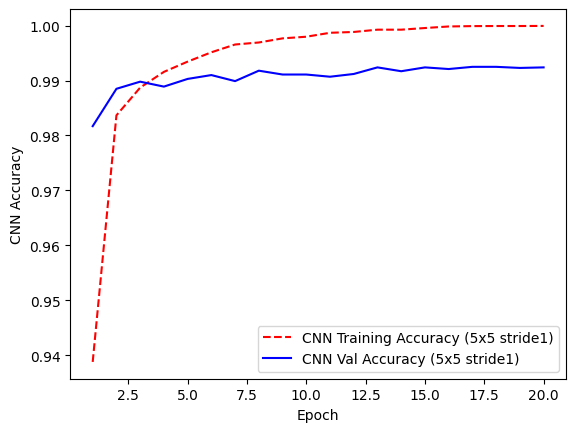

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.9900 - loss: 0.0405
Validation Accuracy (5x5 filter, stride=1): 0.9923999905586243


In [ ]:
# Plot for 3.10: 5x5 filter with Stride=1
training_acc = cnn_hist_5x5.history['accuracy']
val_acc = cnn_hist_5x5.history['val_accuracy']

epoch_count = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['CNN Training Accuracy (5x5 stride1)', 'CNN Val Accuracy (5x5 stride1)'])
plt.xlabel('Epoch')
plt.ylabel('CNN Accuracy')
plt.show()

val_loss, val_acc = cnn_model_5x5.evaluate(val_images, val_labels)
print('Validation Accuracy (5x5 filter, stride=1):', val_acc)

In [ ]:
# 3.11) Filter Size (Stride Length) - 5x5 (Stride=2)
cnn_model_5x5_stride2 = build_cnn_model(activation_hidden='relu', activation_output='softmax',
                                       filter1_size=5, filter2_size=5,
                                       stride1=2, stride2=1)  # stride=2 on the 1st layer

cnn_model_5x5_stride2.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model_5x5_stride2.build((None, train_images.shape[1], train_images.shape[2], train_images.shape[3]))
cnn_model_5x5_stride2.summary()

BATCH_SIZE = 64
EPOCHS = 20

cnn_hist_5x5_stride2 = cnn_model_5x5_stride2.fit(train_images, train_labels, validation_data=(val_images, val_labels), batch_size=BATCH_SIZE, epochs=EPOCHS)

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 12, 12, 32)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 2, 2, 64)       │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_22 (Flatten)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 900)            │        58,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 10)             │         9,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119,606 (467.21 KB)

 Trainable params: 119,606 (467.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.7206 - loss: 0.8629 - val_accuracy: 0.8761 - val_loss: 0.3842
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9709 - loss: 0.0928 - val_accuracy: 0.9731 - val_loss: 0.0794
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9826 - loss: 0.0566 - val_accuracy: 0.9827 - val_loss: 0.0572
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9867 - loss: 0.0422 - val_accuracy: 0.9869 - val_loss: 0.0399
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - accuracy: 0.9905 - loss: 0.0318 - val_accuracy: 0.9845 - val_loss: 0.0504
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9913 - loss: 0.0285 - val_accuracy: 0.9868 - val_loss: 0.0422
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - accuracy: 0.9942 - loss: 0.0213 - val_accuracy: 0.9876 - val_loss: 0.0395
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.9951 - loss: 0.0177 - 

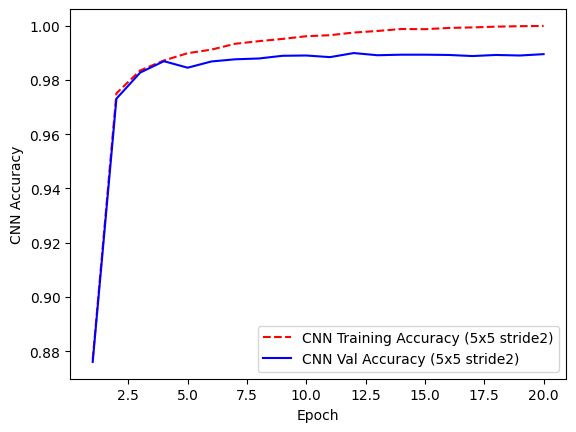

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9866 - loss: 0.0513
Validation Accuracy (5x5 filter, stride=2): 0.9894999861717224


In [ ]:
# Plot for 3.11: 5x5 filter with stride=2
training_acc = cnn_hist_5x5_stride2.history['accuracy']
val_acc = cnn_hist_5x5_stride2.history['val_accuracy']

epoch_count = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['CNN Training Accuracy (5x5 stride2)', 'CNN Val Accuracy (5x5 stride2)'])
plt.xlabel('Epoch')
plt.ylabel('CNN Accuracy')
plt.show()

val_loss, val_acc = cnn_model_5x5_stride2.evaluate(val_images, val_labels)
print('Validation Accuracy (5x5 filter, stride=2):', val_acc)

In [ ]:
# 3.12) Filter Size (Stride Length) - 7x7 (Stride=1)
cnn_model_7x7 = build_cnn_model(activation_hidden='relu', activation_output='softmax',
                               filter1_size=7, filter2_size=7,
                               stride1=1, stride2=1)

cnn_model_7x7.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model_7x7.build((None, train_images.shape[1], train_images.shape[2], train_images.shape[3]))
cnn_model_7x7.summary()

BATCH_SIZE = 64
EPOCHS = 20

cnn_hist_7x7 = cnn_model_7x7.fit(train_images, train_labels, validation_data=(val_images, val_labels), batch_size=BATCH_SIZE, epochs=EPOCHS)

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 22, 22, 32)     │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 5, 5, 64)       │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_23 (Flatten)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 900)            │       231,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 10)             │         9,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 342,326 (1.31 MB)

 Trainable params: 342,326 (1.31 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 70s 74ms/step - accuracy: 0.8165 - loss: 0.5876 - val_accuracy: 0.9782 - val_loss: 0.0665
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 73s 78ms/step - accuracy: 0.9785 - loss: 0.0682 - val_accuracy: 0.9821 - val_loss: 0.0554
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 76s 71ms/step - accuracy: 0.9866 - loss: 0.0443 - val_accuracy: 0.9804 - val_loss: 0.0596
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 68s 73ms/step - accuracy: 0.9902 - loss: 0.0314 - val_accuracy: 0.9884 - val_loss: 0.0326
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 67s 71ms/step - accuracy: 0.9924 - loss: 0.0246 - val_accuracy: 0.9861 - val_loss: 0.0398
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 67s 71ms/step - accuracy: 0.9933 - loss: 0.0213 - val_accuracy: 0.9876 - val_loss: 0.0324
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 66s 71ms/step - accuracy: 0.9951 - loss: 0.0159 - val_accuracy: 0.9896 - val_loss: 0.0350
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 84s 73ms/step - accuracy: 0.9960 - loss: 0.0135 - 

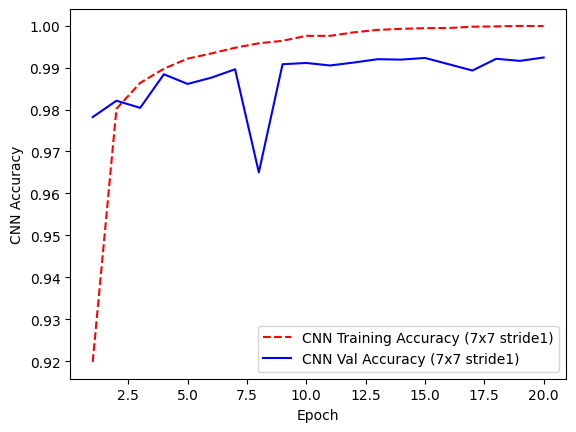

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9888 - loss: 0.0476
Validation Accuracy (7x7 filter, stride=1): 0.9923999905586243


In [ ]:
# Plot for 3.12: 7x7 filter with Stride=1
training_acc = cnn_hist_7x7.history['accuracy']
val_acc = cnn_hist_7x7.history['val_accuracy']

epoch_count = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['CNN Training Accuracy (7x7 stride1)', 'CNN Val Accuracy (7x7 stride1)'])
plt.xlabel('Epoch')
plt.ylabel('CNN Accuracy')
plt.show()

val_loss, val_acc = cnn_model_7x7.evaluate(val_images, val_labels)
print('Validation Accuracy (7x7 filter, stride=1):', val_acc)

In [ ]:
# 3.14) The Two Pooling Layers - AveragePool & AveragePool
cnn_model_avgpool = build_cnn_model(activation_hidden='relu', activation_output='softmax',
                                   pool1_type='avg', pool2_type='avg')

cnn_model_avgpool.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model_avgpool.build((None, train_images.shape[1], train_images.shape[2], train_images.shape[3]))
cnn_model_avgpool.summary()

BATCH_SIZE = 64
EPOCHS = 20

cnn_hist_avgpool = cnn_model_avgpool.fit(train_images, train_labels, validation_data=(val_images, val_labels), batch_size=BATCH_SIZE, epochs=EPOCHS)

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 13, 13, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_24 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 900)            │     1,440,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 10)             │         9,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,468,726 (5.60 MB)

 Trainable params: 1,468,726 (5.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 53s 56ms/step - accuracy: 0.8008 - loss: 0.6407 - val_accuracy: 0.9691 - val_loss: 0.1058
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 53s 57ms/step - accuracy: 0.9678 - loss: 0.1022 - val_accuracy: 0.9807 - val_loss: 0.0657
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 83s 57ms/step - accuracy: 0.9794 - loss: 0.0675 - val_accuracy: 0.9775 - val_loss: 0.0669
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 52s 55ms/step - accuracy: 0.9827 - loss: 0.0539 - val_accuracy: 0.9818 - val_loss: 0.0534
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 84s 58ms/step - accuracy: 0.9869 - loss: 0.0421 - val_accuracy: 0.9740 - val_loss: 0.0845
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 54s 58ms/step - accuracy: 0.9887 - loss: 0.0357 - val_accuracy: 0.9841 - val_loss: 0.0470
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 52s 56ms/step - accuracy: 0.9914 - loss: 0.0273 - val_accuracy: 0.9870 - val_loss: 0.0437
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 52s 56ms/step - accuracy: 0.9920 - loss: 0.0260 - 

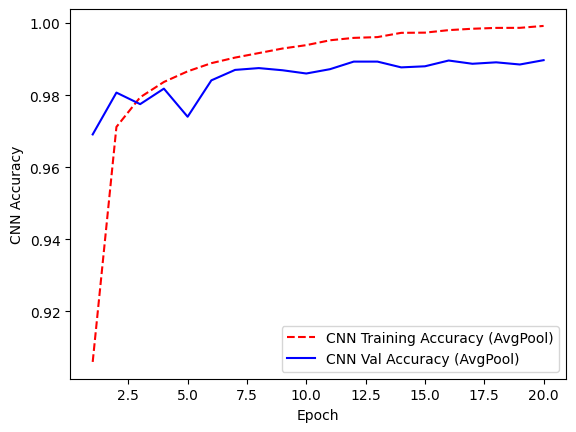

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9858 - loss: 0.0495
Validation Accuracy (AveragePool): 0.9897000193595886


In [ ]:
# Plot for 3.14: AveragePool & AveragePool
training_acc = cnn_hist_avgpool.history['accuracy']
val_acc = cnn_hist_avgpool.history['val_accuracy']

epoch_count = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['CNN Training Accuracy (AvgPool)', 'CNN Val Accuracy (AvgPool)'])
plt.xlabel('Epoch')
plt.ylabel('CNN Accuracy')
plt.show()

val_loss, val_acc = cnn_model_avgpool.evaluate(val_images, val_labels)
print('Validation Accuracy (AveragePool):', val_acc)

In [ ]:
# 3.15) The Two Pooling Layers - Maxpool & AveragePool
cnn_model_mixedpool = build_cnn_model(activation_hidden='relu', activation_output='softmax',
                                     pool1_type='max', pool2_type='avg')

cnn_model_mixedpool.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model_mixedpool.build((None, train_images.shape[1], train_images.shape[2], train_images.shape[3]))
cnn_model_mixedpool.summary()

BATCH_SIZE = 64
EPOCHS = 20

cnn_hist_mixedpool = cnn_model_mixedpool.fit(train_images, train_labels, validation_data=(val_images, val_labels), batch_size=BATCH_SIZE, epochs=EPOCHS)

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 5, 5, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_25 (Flatten)            │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 900)            │     1,440,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 10)             │         9,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,468,726 (5.60 MB)

 Trainable params: 1,468,726 (5.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 67s 71ms/step - accuracy: 0.8203 - loss: 0.5838 - val_accuracy: 0.9728 - val_loss: 0.0854
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 60s 64ms/step - accuracy: 0.9722 - loss: 0.0903 - val_accuracy: 0.9735 - val_loss: 0.0847
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 63ms/step - accuracy: 0.9805 - loss: 0.0621 - val_accuracy: 0.9829 - val_loss: 0.0495
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 84s 66ms/step - accuracy: 0.9856 - loss: 0.0443 - val_accuracy: 0.9841 - val_loss: 0.0493
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 60s 64ms/step - accuracy: 0.9883 - loss: 0.0370 - val_accuracy: 0.9860 - val_loss: 0.0456
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 58s 62ms/step - accuracy: 0.9908 - loss: 0.0292 - val_accuracy: 0.9888 - val_loss: 0.0366
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 60s 64ms/step - accuracy: 0.9921 - loss: 0.0253 - val_accuracy: 0.9852 - val_loss: 0.0465
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 62s 66ms/step - accuracy: 0.9934 - loss: 0.0218 - 

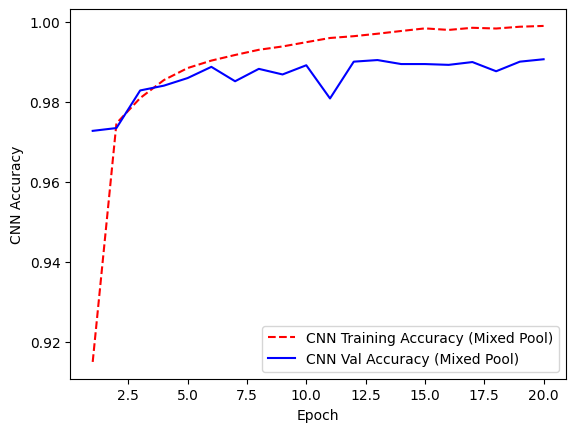

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9878 - loss: 0.0482
Validation Accuracy (Mixed Pooling): 0.9907000064849854


In [ ]:
# Plot for 3.15: Maxpool & AveragePool
training_acc = cnn_hist_mixedpool.history['accuracy']
val_acc = cnn_hist_mixedpool.history['val_accuracy']

epoch_count = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['CNN Training Accuracy (Mixed Pool)', 'CNN Val Accuracy (Mixed Pool)'])
plt.xlabel('Epoch')
plt.ylabel('CNN Accuracy')
plt.show()

val_loss, val_acc = cnn_model_mixedpool.evaluate(val_images, val_labels)
print('Validation Accuracy (Mixed Pooling):', val_acc)

In [ ]:
# 3.17) Optimizer - SGD with learning_rate=0.01
cnn_model_sgd_low = build_cnn_model(activation_hidden='relu', activation_output='softmax')

cnn_model_sgd_low.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

BATCH_SIZE = 64
EPOCHS = 20

cnn_hist_sgd_low = cnn_model_sgd_low.fit(train_images, train_labels, validation_data=(val_images, val_labels), batch_size=BATCH_SIZE, epochs=EPOCHS)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 62s 65ms/step - accuracy: 0.6121 - loss: 1.3496 - val_accuracy: 0.9269 - val_loss: 0.2461
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 64ms/step - accuracy: 0.9329 - loss: 0.2218 - val_accuracy: 0.9580 - val_loss: 0.1466
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 62s 66ms/step - accuracy: 0.9572 - loss: 0.1443 - val_accuracy: 0.9648 - val_loss: 0.1180
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 61s 65ms/step - accuracy: 0.9671 - loss: 0.1084 - val_accuracy: 0.9711 - val_loss: 0.0875
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 64ms/step - accuracy: 0.9721 - loss: 0.0932 - val_accuracy: 0.9768 - val_loss: 0.0738
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 83s 65ms/step - accuracy: 0.9747 - loss: 0.0820 - val_accuracy: 0.9794 - val_loss: 0.0654
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 60s 64ms/step - accuracy: 0.9781 - loss: 0.0729 - val_accuracy: 0.9807 - val_loss: 0.0631
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 59s 63ms/step - accuracy: 0.9801 - loss: 0.0632 - 

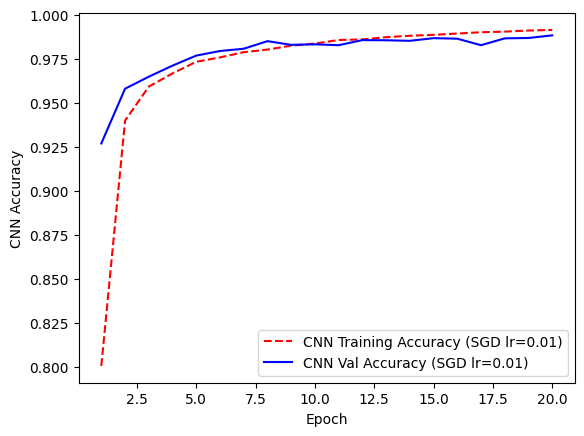

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9862 - loss: 0.0447
Validation Accuracy (SGD lr=0.01): 0.9883000254631042


In [ ]:
# Plot for 3.17: SGD with learning_rate=0.01
training_acc = cnn_hist_sgd_low.history['accuracy']
val_acc = cnn_hist_sgd_low.history['val_accuracy']

epoch_count = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['CNN Training Accuracy (SGD lr=0.01)', 'CNN Val Accuracy (SGD lr=0.01)'])
plt.xlabel('Epoch')
plt.ylabel('CNN Accuracy')
plt.show()

val_loss, val_acc = cnn_model_sgd_low.evaluate(val_images, val_labels)
print('Validation Accuracy (SGD lr=0.01):', val_acc)

In [ ]:
# 3.18) Optimizer - ADAM with learning_rate=0.001
cnn_model_adam = build_cnn_model(activation_hidden='relu', activation_output='softmax')

cnn_model_adam.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

BATCH_SIZE = 64
EPOCHS = 20

cnn_hist_adam = cnn_model_adam.fit(train_images, train_labels, validation_data=(val_images, val_labels), batch_size=BATCH_SIZE, epochs=EPOCHS)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 68s 71ms/step - accuracy: 0.9117 - loss: 0.2791 - val_accuracy: 0.9851 - val_loss: 0.0442
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 65s 70ms/step - accuracy: 0.9873 - loss: 0.0420 - val_accuracy: 0.9887 - val_loss: 0.0309
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 66s 71ms/step - accuracy: 0.9923 - loss: 0.0253 - val_accuracy: 0.9862 - val_loss: 0.0431
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 71ms/step - accuracy: 0.9940 - loss: 0.0198 - val_accuracy: 0.9916 - val_loss: 0.0252
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 68s 72ms/step - accuracy: 0.9960 - loss: 0.0115 - val_accuracy: 0.9909 - val_loss: 0.0288
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 83s 73ms/step - accuracy: 0.9970 - loss: 0.0093 - val_accuracy: 0.9918 - val_loss: 0.0287
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 79s 70ms/step - accuracy: 0.9969 - loss: 0.0087 - val_accuracy: 0.9907 - val_loss: 0.0323
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 85s 73ms/step - accuracy: 0.9980 - loss: 0.0066 - 

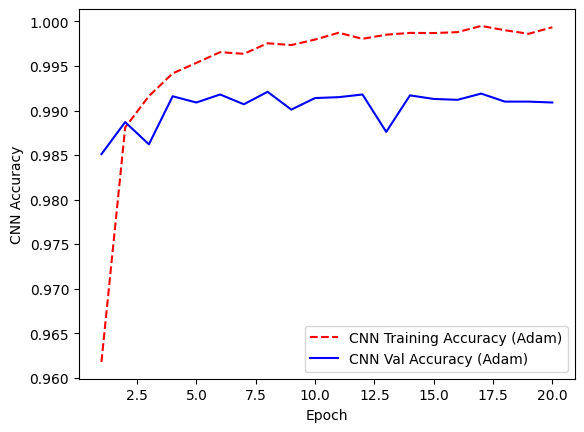

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9884 - loss: 0.0541
Validation Accuracy (Adam): 0.9908999800682068


In [ ]:
# Plot for 3.18: ADAM
training_acc = cnn_hist_adam.history['accuracy']
val_acc = cnn_hist_adam.history['val_accuracy']

epoch_count = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['CNN Training Accuracy (Adam)', 'CNN Val Accuracy (Adam)'])
plt.xlabel('Epoch')
plt.ylabel('CNN Accuracy')
plt.show()

val_loss, val_acc = cnn_model_adam.evaluate(val_images, val_labels)
print('Validation Accuracy (Adam):', val_acc)

In [ ]:
# 3.19) Optimizer - RMSprop with learning_rate=0.001
cnn_model_rmsprop = build_cnn_model(activation_hidden='relu', activation_output='softmax')

cnn_model_rmsprop.compile(
    optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

BATCH_SIZE = 64
EPOCHS = 20

cnn_hist_rmsprop = cnn_model_rmsprop.fit(train_images, train_labels, validation_data=(val_images, val_labels), batch_size=BATCH_SIZE, epochs=EPOCHS)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 80s 84ms/step - accuracy: 0.9027 - loss: 0.3173 - val_accuracy: 0.9861 - val_loss: 0.0421
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 75s 76ms/step - accuracy: 0.9884 - loss: 0.0377 - val_accuracy: 0.9893 - val_loss: 0.0310
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 80s 75ms/step - accuracy: 0.9925 - loss: 0.0234 - val_accuracy: 0.9861 - val_loss: 0.0427
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 68s 73ms/step - accuracy: 0.9956 - loss: 0.0150 - val_accuracy: 0.9898 - val_loss: 0.0358
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 73ms/step - accuracy: 0.9963 - loss: 0.0111 - val_accuracy: 0.9923 - val_loss: 0.0257
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 72ms/step - accuracy: 0.9980 - loss: 0.0065 - val_accuracy: 0.9914 - val_loss: 0.0300
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 68s 73ms/step - accuracy: 0.9986 - loss: 0.0049 - val_accuracy: 0.9922 - val_loss: 0.0305
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 69s 73ms/step - accuracy: 0.9989 - loss: 0.0038 - 

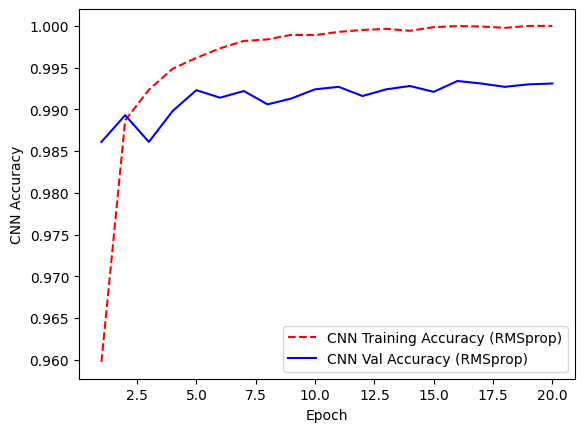

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9905 - loss: 0.0667
Validation Accuracy (RMSprop): 0.9930999875068665


In [ ]:
# Plot for 3.19: RMSprop
training_acc = cnn_hist_rmsprop.history['accuracy']
val_acc = cnn_hist_rmsprop.history['val_accuracy']

epoch_count = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['CNN Training Accuracy (RMSprop)', 'CNN Val Accuracy (RMSprop)'])
plt.xlabel('Epoch')
plt.ylabel('CNN Accuracy')
plt.show()

val_loss, val_acc = cnn_model_rmsprop.evaluate(val_images, val_labels)
print('Validation Accuracy (RMSprop):', val_acc)

In [ ]:
# 3.21) Loss - Categorical Crossentropy
train_labels_onehot = tf.keras.utils.to_categorical(train_labels, 10)
val_labels_onehot = tf.keras.utils.to_categorical(val_labels, 10)

cnn_model_categorical = build_cnn_model(activation_hidden='relu', activation_output='softmax')

cnn_model_categorical.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

BATCH_SIZE = 64
EPOCHS = 20

cnn_hist_categorical = cnn_model_categorical.fit(train_images, train_labels_onehot, validation_data=(val_images, val_labels_onehot), batch_size=BATCH_SIZE, epochs=EPOCHS)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 69s 72ms/step - accuracy: 0.9166 - loss: 0.2804 - val_accuracy: 0.9839 - val_loss: 0.0479
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 67s 71ms/step - accuracy: 0.9879 - loss: 0.0374 - val_accuracy: 0.9888 - val_loss: 0.0339
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 66s 71ms/step - accuracy: 0.9917 - loss: 0.0249 - val_accuracy: 0.9905 - val_loss: 0.0323
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 66s 70ms/step - accuracy: 0.9950 - loss: 0.0171 - val_accuracy: 0.9913 - val_loss: 0.0268
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 66s 70ms/step - accuracy: 0.9963 - loss: 0.0119 - val_accuracy: 0.9900 - val_loss: 0.0296
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 85s 73ms/step - accuracy: 0.9968 - loss: 0.0097 - val_accuracy: 0.9907 - val_loss: 0.0334
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 79s 71ms/step - accuracy: 0.9974 - loss: 0.0080 - val_accuracy: 0.9901 - val_loss: 0.0350
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 83s 71ms/step - accuracy: 0.9978 - loss: 0.0059 - 

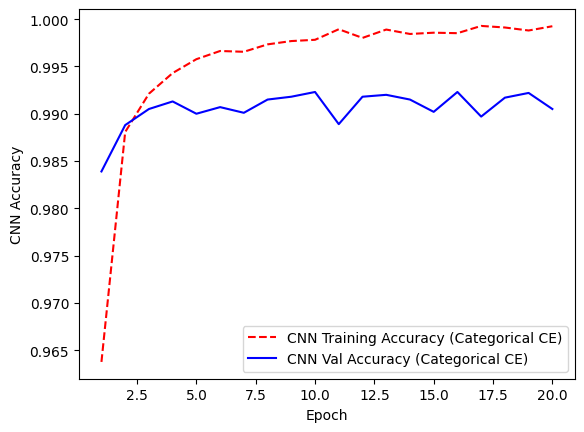

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9869 - loss: 0.0656
Validation Accuracy (Categorical Crossentropy): 0.9904999732971191


In [ ]:
# Plot for 3.21: Categorical Crossentropy
training_acc = cnn_hist_categorical.history['accuracy']
val_acc = cnn_hist_categorical.history['val_accuracy']

epoch_count = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['CNN Training Accuracy (Categorical CE)', 'CNN Val Accuracy (Categorical CE)'])
plt.xlabel('Epoch')
plt.ylabel('CNN Accuracy')
plt.show()

val_loss, val_acc = cnn_model_categorical.evaluate(val_images, val_labels_onehot)
print('Validation Accuracy (Categorical Crossentropy):', val_acc)

In [ ]:
# 3.22) Loss - Mean Squared Error (MSE)
cnn_model_mse = build_cnn_model(activation_hidden='relu', activation_output='softmax')

cnn_model_mse.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='mean_squared_error',
    metrics=['accuracy']
)

BATCH_SIZE = 64
EPOCHS = 20

cnn_hist_mse = cnn_model_mse.fit(train_images, train_labels_onehot, validation_data=(val_images, val_labels_onehot), batch_size=BATCH_SIZE, epochs=EPOCHS)

Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 68s 71ms/step - accuracy: 0.9018 - loss: 0.0139 - val_accuracy: 0.9860 - val_loss: 0.0022
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 68s 72ms/step - accuracy: 0.9860 - loss: 0.0022 - val_accuracy: 0.9899 - val_loss: 0.0017
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 72ms/step - accuracy: 0.9908 - loss: 0.0014 - val_accuracy: 0.9882 - val_loss: 0.0018
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 79s 69ms/step - accuracy: 0.9931 - loss: 0.0011 - val_accuracy: 0.9888 - val_loss: 0.0016
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 65s 70ms/step - accuracy: 0.9948 - loss: 8.0317e-04 - val_accuracy: 0.9908 - val_loss: 0.0014
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 69ms/step - accuracy: 0.9945 - loss: 8.1804e-04 - val_accuracy: 0.9896 - val_loss: 0.0017
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 66s 70ms/step - accuracy: 0.9954 - loss: 7.0846e-04 - val_accuracy: 0.9908 - val_loss: 0.0014
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 70ms/step - accuracy: 0.9962 - los

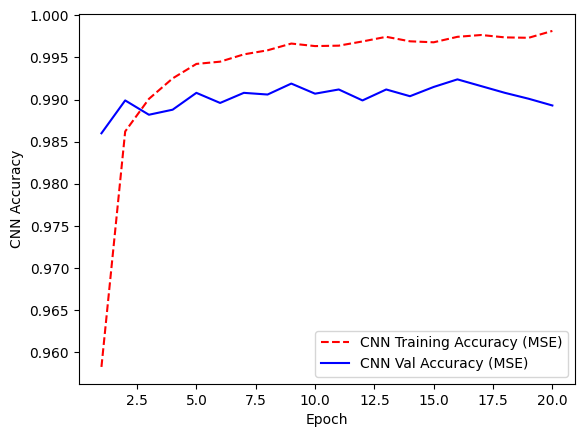

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9870 - loss: 0.0023
Validation Accuracy (MSE): 0.989300012588501


In [ ]:
# Plot for 3.22: Mean Squared Error (MSE)
training_acc = cnn_hist_mse.history['accuracy']
val_acc = cnn_hist_mse.history['val_accuracy']

epoch_count = range(1, EPOCHS + 1)

plt.figure()
plt.plot(epoch_count, training_acc, 'r--')
plt.plot(epoch_count, val_acc, 'b-')
plt.legend(['CNN Training Accuracy (MSE)', 'CNN Val Accuracy (MSE)'])
plt.xlabel('Epoch')
plt.ylabel('CNN Accuracy')
plt.show()

val_loss, val_acc = cnn_model_mse.evaluate(val_images, val_labels_onehot)
print('Validation Accuracy (MSE):', val_acc)

#### Think About the Following

**What is the highest accuracy you’re able to achieve using the CNN model, and how does the accuracy of the CNN model compare to the accuracy of the simple fully connected network?** Accordingly, answer Question 3.23 in the report

#### Machine Learning Interpretability

For this part, we will have a look at using SHAP for machine learning interpretability analysis.

A crucial part of studying machine learning models is analyzing what they are doing to make sure that the model really understands the problem and is not overfitting the data or focusing on incorrect features.

This helps us identify the model weaknesses and thus improve its performance on unseen data.

One of the ways to do so is to determine and analyze the features affecting the model's prediction. You can read more about machine learning interpretability in this [article](https://towardsdatascience.com/understanding-machine-learning-interpretability-168fd7562a1a).

[SHAP](https://shap.readthedocs.io/en/latest/overviews.html) is a technique that leverages game theory to explain the prediction by identifying the contribution of each feature on the model's final decision. You can read about other techniques in this [article](https://towardsdatascience.com/three-interpretability-methods-to-consider-when-developing-your-machine-learning-model-5bf368b47fac).

For this part, we will use the **DeepExplainer** provided by SHAP for analyzing the performance of **the best CNN model** you created on the MNIST dataset.

**You can find details about how to do so [here](https://shap.readthedocs.io/en/latest/example_notebooks/image_examples/image_classification/Front%20Page%20DeepExplainer%20MNIST%20Example.html).**

##### Installing SHAP

In [ ]:
!pip install shap

##### Importing and using SHAP

In [ ]:
import shap
import numpy as np

np.random.seed(42)
random_indices = np.random.choice(len(train_images), size=1000, replace=False)
background = train_images[random_indices]

# Intiating the deep explainer with Dropout from 3.7 because that was the best CNN model
e = shap.DeepExplainer(cnn_model_dropout, background)

# Obtaining the SHAP values on the first 10 images
shap_values = e.shap_values(val_images[1:11])

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_124
Received: inputs=['Tensor(shape=(1000, 28, 28, 1))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_124
Received: inputs=['Tensor(shape=(2000, 28, 28, 1))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_124
Received: inputs=['Tensor(shape=(10

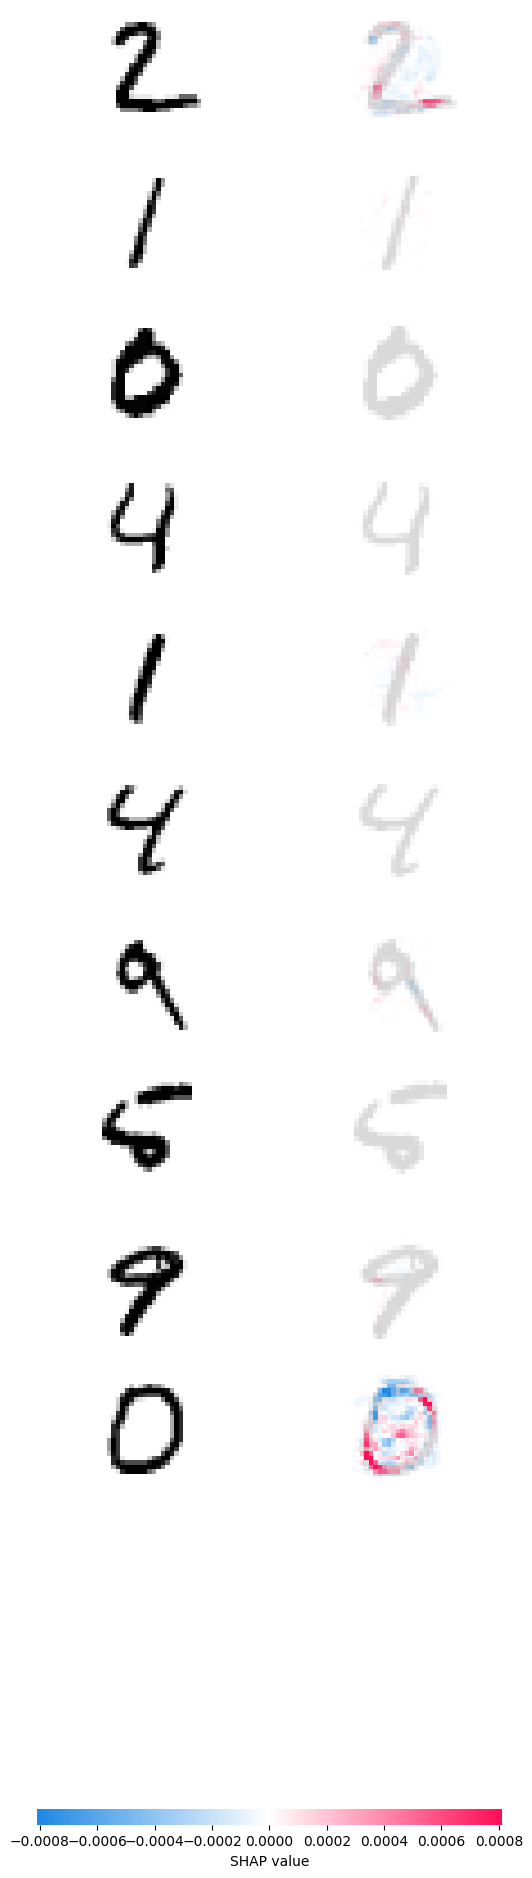

In [ ]:
# plot to see where did the model concentrate to classify the images
shap.image_plot(shap_values,-val_images[1:11])

**Think about the following:**

*What does the plot show in each entry? What can you conclude from the plot? Is the model focusing on meaningful features? Why? Why not? Are there features in certain digits that confuse the model?*

***Make sure to include the SHAP plot you obtained and your comments/observations in the report for the TODOs numbered 4.2 and 4.3***

## 1.3 Conclusion

That's it! Congratulations on training multinominal classification models.

Make sure you deliver all the requirements for the submission.